In [1]:
from calendar import c
import re
import fastf1 as ff1
import pandas as pd
from datetime import date 
from fastf1 import utils
from matplotlib.offsetbox import OffsetImage,AnnotationBbox
from matplotlib.offsetbox import (OffsetImage, AnnotationBbox)
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

In [2]:
import numpy as np
from scipy import interpolate
import pandas as pd

def interpolate_telemetry(telemetry_df, new_distance_step=1.0):
    """
    Interpolate telemetry data to have points at regular intervals with specific
    interpolation methods for different data types.
    """
    original_distance = telemetry_df['Distance'].values
    
    # Create new distance points with regular intervals
    new_distance = np.arange(
        original_distance[0], 
        original_distance[-1], 
        new_distance_step
    )
    
    # Create a new DataFrame to hold interpolated data
    interpolated_df = pd.DataFrame({'Distance': new_distance})
    
    # Define appropriate interpolation types for different columns
    discrete_columns = ['nGear', 'DRS']  # Columns that should use 'nearest'
    
    # Interpolate each column
    for column in telemetry_df.columns:
        if column != 'Distance':
            # Choose interpolation type based on column
            if column in discrete_columns:
                interp_kind = 'nearest'
            elif column in ['Speed', 'RPM', 'Throttle', 'Brake']:
                interp_kind = 'linear'
            else:
                interp_kind = 'linear'
                
            # Create an interpolation function for this column
            f = interpolate.interp1d(
                original_distance,
                telemetry_df[column].values,
                kind=interp_kind,
                bounds_error=False,
                fill_value=(telemetry_df[column].iloc[0], telemetry_df[column].iloc[-1])
            )
            
            # Apply the interpolation function to get new values
            interpolated_df[column] = f(new_distance)
            
            # Redondear valores enteros si es necesario
            if column in discrete_columns:
                interpolated_df[column] = interpolated_df[column].round().astype(int)
    
    return interpolated_df

def get_lapFromObject(laptime):
    
    l = []
    characters = "days "
    for i in range(len(characters)):
        laptime = laptime.replace(characters[i],"")
    
    laptime = re.sub(r'.', '', laptime, count = 5)
    if "000" in laptime:
        laptime = laptime.replace("000","")
    l = laptime.split()
    lap = l[0]
   

    while True:
        if(len(lap) <= 8):
            if lap[0] == ":" or lap[0] == "0" :
                if len(lap) == 1:
                    lap = '2:00.000'
                else:
                    lap= lap[1:]
            else:
                break
        else:
            lap= lap[1:]
    diferencia = 8- len(lap)
    arraDif = ".000"
    if len(lap) < 8:
        lap = lap + arraDif[-abs(diferencia):]
    return lap

def fill_fastest_values(delta_df):
    """
    Rellena los valores 0 en la columna 'Fastest' con el último valor no-cero (1 o -1).
    
    Args:
        delta_df: DataFrame con la columna 'Fastest' que contiene valores -1, 0, 1
        
    Returns:
        DataFrame con los valores 0 en 'Fastest' reemplazados
    """
    # Crear una copia para no modificar el original
    df = delta_df.copy()
    
    # Asegurarse de que los datos estén ordenados
    df = df.sort_index()
    
    # Valor actual para rellenar (inicializar con el primer valor no-cero)
    first_non_zero_idx = df[df['Fastest'] != 0]['Fastest'].first_valid_index()
    
    # Si no hay valores no-cero, no hay nada que hacer
    if first_non_zero_idx is None:
        return df
    
    current_fill_value = df.loc[first_non_zero_idx, 'Fastest']
    
    # Rellenar los valores 0 con el último valor no-cero
    for idx in df.index:
        if df.loc[idx, 'Fastest'] == 0:
            df.loc[idx, 'Fastest'] = current_fill_value
        else:
            # Actualizar el valor de relleno cuando encontramos un valor no-cero
            current_fill_value = df.loc[idx, 'Fastest']
    
    return df

# Detectar crestas y valles en los datos de velocidad
def detect_peaks_and_valleys(x, y, prominence=10, distance=150):
    """
    Detecta crestas (máximos) y valles (mínimos) en los datos.
    
    Args:
        x: Array con las distancias
        y: Array con las velocidades
        prominence: Prominencia mínima para considerar un punto como cresta o valle
        distance: Distancia mínima entre picos consecutivos
    
    Returns:
        peaks_indices: Índices de las crestas (máximos)
        valleys_indices: Índices de los valles (mínimos)
    """
    from scipy.signal import find_peaks
    
    # Encontrar crestas (máximos)
    peaks_indices, _ = find_peaks(y, prominence=prominence, distance=distance)
    
    # Encontrar valles (mínimos) (invirtiendo los datos)
    valleys_indices, _ = find_peaks(-y, prominence=prominence, distance=distance)
    
    return peaks_indices, valleys_indices

def add_speed_annotations(fig, x1, y1, x2, y2, name1, name2, color1, color2, row=1, col=1, offset=20, min_peak_speed=250):
    """
    Añade anotaciones para velocidades máximas (crestas) y mínimas (valles).
    - Para máximos: Solo muestra los que superen min_peak_speed
    - Para mínimos: Compara valores cercanos (hasta 100m de diferencia) y siempre muestra menor abajo
    
    Args:
        fig: Figura de Plotly
        x1, y1: Arrays con las distancias y velocidades del primer piloto (Sainz)
        x2, y2: Arrays con las distancias y velocidades del segundo piloto (Hamilton)
        name1, name2: Nombres de los pilotos
        color1, color2: Colores para las anotaciones
        row, col: Posición del subplot
        offset: Desplazamiento vertical para las anotaciones
        min_peak_speed: Velocidad mínima para mostrar picos (solo para crestas)
    """
    import numpy as np
    from scipy.signal import find_peaks
    import plotly.graph_objects as go
    
    # Convertir a arrays numpy para operaciones más eficientes
    x1 = np.array(x1)
    y1 = np.array(y1)
    x2 = np.array(x2)
    y2 = np.array(y2)
    
    # Detectar crestas (máximos)
    peaks1_idx, _ = find_peaks(y1, prominence=10, distance=100)
    peaks2_idx, _ = find_peaks(y2, prominence=10, distance=100)
    
    # Detectar valles (mínimos)
    valleys1_idx, _ = find_peaks(-y1, prominence=10, distance=100)
    valleys2_idx, _ = find_peaks(-y2, prominence=10, distance=100)
    
    # Crear listas de puntos con sus coordenadas
    # Para picos, solo incluir aquellos con velocidad > min_peak_speed
    peaks1 = [(x1[i], y1[i]) for i in peaks1_idx if i < len(x1) and y1[i] > min_peak_speed]
    peaks2 = [(x2[i], y2[i]) for i in peaks2_idx if i < len(x2) and y2[i] > min_peak_speed]
    
    # Para valles, incluir todos
    valleys1 = [(x1[i], y1[i]) for i in valleys1_idx if i < len(x1)]
    valleys2 = [(x2[i], y2[i]) for i in valleys2_idx if i < len(x2)]
    
    # Procesar los picos (velocidades máximas) - Comparar en el mismo punto
    all_peaks = []
    
    # Añadir los puntos de pico de Sainz
    for x, y in peaks1:
        all_peaks.append((x, 'peak', 1, y))
    
    # Añadir los puntos de pico de Hamilton
    for x, y in peaks2:
        all_peaks.append((x, 'peak', 2, y))
    
    # Ordenar y agrupar picos
    all_peaks.sort(key=lambda p: p[0])
    
    # Agrupar picos cercanos (dentro de 50m de distancia)
    grouped_peaks = []
    current_group = []
    
    for point in all_peaks:
        if not current_group or abs(point[0] - current_group[0][0]) < 50:
            current_group.append(point)
        else:
            grouped_peaks.append(current_group)
            current_group = [point]
    
    if current_group:
        grouped_peaks.append(current_group)
    
    # Para cada grupo de picos, añadir anotaciones comparando velocidades
    for group in grouped_peaks:
        distances = [p[0] for p in group]
        avg_distance = sum(distances) / len(distances)
        
        # Encontrar las velocidades de ambos pilotos en este punto
        idx1 = np.abs(x1 - avg_distance).argmin()
        idx2 = np.abs(x2 - avg_distance).argmin()
        
        speed1 = y1[idx1]
        speed2 = y2[idx2]
        
        # Para picos, verificar que al menos una de las velocidades sea > min_peak_speed
        if max(speed1, speed2) <= min_peak_speed:
            continue  # Saltar este punto si ninguna velocidad supera el umbral
        
        # Añadir un símbolo para indicar máximo
        fig.add_trace(
            go.Scatter(
                x=[avg_distance],
                y=[(speed1 + speed2) / 2],  # Punto medio entre ambas velocidades
                mode='markers',
                marker=dict(
                    symbol="triangle-up",
                    size=8,
                    color='gray',
                    line=dict(width=1, color='white')
                ),
                showlegend=False,
                hoverinfo='none'
            ),
            row=row+1, col=col
        )
        
        # Añadir anotaciones con la velocidad mayor arriba y menor abajo
        if speed1 >= speed2:
            # Sainz más rápido o igual, va arriba
            fig.add_annotation(
                x=avg_distance,
                y=speed1,
                text=f"{int(speed1)}",
                showarrow=False,
                font=dict(color=color1, size=10),
                xref=f"x",
                yref=f"y{row}",
                yshift=offset,  # Positivo = arriba
                bgcolor="rgba(0,0,0,0.5)",

            )
            
            fig.add_annotation(
                x=avg_distance,
                y=speed2,
                text=f"{int(speed2)}",
                showarrow=False,
                font=dict(color=color2, size=10),
                xref=f"x",
                yref=f"y{row}",
                yshift=-offset,  # Negativo = abajo
                bgcolor="rgba(0,0,0,0.5)",

            )
        else:
            # Hamilton más rápido, va arriba
            fig.add_annotation(
                x=avg_distance,
                y=speed2,
                text=f"{int(speed2)}",
                showarrow=False,
                font=dict(color=color2, size=10),
                xref=f"x",
                yref=f"y{row}",
                yshift=offset,  # Positivo = arriba
                bgcolor="rgba(0,0,0,0.5)",

            )
            
            fig.add_annotation(
                x=avg_distance,
                y=speed1,
                text=f"{int(speed1)}",
                showarrow=False,
                font=dict(color=color1, size=10),
                xref=f"x",
                yref=f"y{row}",
                yshift=-offset,  # Negativo = abajo
                bgcolor="rgba(0,0,0,0.5)",

            )
    
    # Procesar y emparejar valles cercanos (menos de 100m de distancia)
    # Combinar y ordenar todos los valles
    all_valleys = []
    for x, y in valleys1:
        all_valleys.append((x, 1, y))  # 1 = Sainz
    for x, y in valleys2:
        all_valleys.append((x, 2, y))  # 2 = Hamilton
    
    all_valleys.sort(key=lambda v: v[0])  # Ordenar por distancia
    
    # Emparejar valles cercanos
    i = 0
    while i < len(all_valleys):
        current = all_valleys[i]
        
        # Buscar otro valle cercano del otro piloto
        j = i + 1
        found_pair = False
        
        while j < len(all_valleys) and all_valleys[j][0] - current[0] <= 100:
            if all_valleys[j][1] != current[1]:  # Diferente piloto
                # Encontramos un par de valles cercanos
                valley1 = current if current[1] == 1 else all_valleys[j]
                valley2 = all_valleys[j] if current[1] == 1 else current
                
                # Obtener posiciones y velocidades
                x_val1, _, y_val1 = valley1
                x_val2, _, y_val2 = valley2
                
                # Calcular posición promedio para el marcador
                avg_x = (x_val1 + x_val2) / 2
                
                # Añadir un símbolo para indicar mínimo en la posición promedio
                fig.add_trace(
                    go.Scatter(
                        x=[avg_x],
                        y=[(y_val1 + y_val2) / 2],  # Punto medio entre ambas velocidades
                        mode='markers',
                        marker=dict(
                            symbol="triangle-down",
                            size=8,
                            color='gray',
                            line=dict(width=1, color='white')
                        ),
                        showlegend=False,
                        hoverinfo='none'
                    ),
                    row=row+1, col=col
                )
                
                # Determinar cuál velocidad es menor y cuál es mayor
                # Siempre mostrar la menor abajo y la mayor arriba
                if y_val1 <= y_val2:
                    # Sainz más lento, va abajo
                    fig.add_annotation(
                        x=avg_x,
                        y=y_val1,
                        text=f"{int(y_val1)}",
                        showarrow=False,
                        font=dict(color=color1, size=10),
                        xref=f"x",
                        yref=f"y{row}",
                        yshift=-offset,  # Negativo = abajo
                        bgcolor="rgba(0,0,0,0.5)",

                    )
                    
                    fig.add_annotation(
                        x=avg_x,
                        y=y_val2,
                        text=f"{int(y_val2)}",
                        showarrow=False,
                        font=dict(color=color2, size=10),
                        xref=f"x",
                        yref=f"y{row}",
                        yshift=offset,  # Positivo = arriba
                        bgcolor="rgba(0,0,0,0.5)",

                    )
                else:
                    # Hamilton más lento, va abajo
                    fig.add_annotation(
                        x=avg_x,
                        y=y_val2,
                        text=f"{int(y_val2)}",
                        showarrow=False,
                        font=dict(color=color2, size=10),
                        xref=f"x",
                        yref=f"y{row}",
                        yshift=-offset,  # Negativo = abajo
                        bgcolor="rgba(0,0,0,0.5)",

                    )
                    
                    fig.add_annotation(
                        x=avg_x,
                        y=y_val1,
                        text=f"{int(y_val1)}",
                        showarrow=False,
                        font=dict(color=color1, size=10),
                        xref=f"x",
                        yref=f"y{row}",
                        yshift=offset,  # Positivo = arriba
                        bgcolor="rgba(0,0,0,0.5)",

                    )
                
                # Marcar como encontrado y avanzar
                found_pair = True
                i = j + 1
                break
            j += 1
        
        if not found_pair:
            # No encontramos pareja cercana, mostrar solo este valle
            x_val, pilot, y_val = current
            
            # Añadir un símbolo para indicar mínimo
            fig.add_trace(
                go.Scatter(
                    x=[x_val],
                    y=[y_val],
                    mode='markers',
                    marker=dict(
                        symbol="triangle-down",
                        size=8,
                        color='gray',
                        line=dict(width=1, color='white')
                    ),
                    showlegend=False,
                    hoverinfo='none'
                ),
                row=row+1, col=col
            )
            
            # Añadir etiqueta con la velocidad mínima
            if pilot == 1:  # Sainz
                fig.add_annotation(
                    x=x_val,
                    y=y_val,
                    text=f"{int(y_val)}",
                    showarrow=False,
                    font=dict(color=color1, size=10),
                    xref=f"x",
                    yref=f"y{row}",
                    yshift=-offset/2,  # Ligeramente abajo
                    bgcolor="rgba(0,0,0,0.5)",

                )
            else:  # Hamilton
                fig.add_annotation(
                    x=x_val,
                    y=y_val,
                    text=f"{int(y_val)}",
                    showarrow=False,
                    font=dict(color=color2, size=10),
                    xref=f"x",
                    yref=f"y{row}",
                    yshift=-offset/2,  # Ligeramente abajo
                    bgcolor="rgba(0,0,0,0.5)",

                )
            i += 1

In [3]:
session = ff1.get_session(2025, 3, 'FP1')
session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (241.69 MB) C:\Users\Danie\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Japanese Grand Prix - Practice 1 [v3.4.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '44', '55', '62', '63', '81', '

In [4]:
driver1 = session.laps.pick_driver('VER').pick_fastest()
fl1_tel = driver1.get_car_data().add_distance().add_differential_distance().add_relative_distance().add_driver_ahead()#Position data
print(driver1)

c:\Users\Danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\fastf1\core.py:3022: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Time                      0 days 00:48:43.533000
Driver                                       VER
DriverNumber                                   1
LapTime                   0 days 00:01:29.065000
LapNumber                                   10.0
Stint                                        3.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:30.950000
Sector2Time               0 days 00:00:40.619000
Sector3Time               0 days 00:00:17.496000
Sector1SessionTime        0 days 00:47:45.418000
Sector2SessionTime        0 days 00:48:26.037000
Sector3SessionTime        0 days 00:48:43.533000
SpeedI1                                    278.0
SpeedI2                                    303.0
SpeedFL                                    270.0
SpeedST                                    304.0
IsPersonalBest                              True
Compound                                    SOFT
TyreLife            

In [5]:





driver1 = session.laps.pick_driver('VER')

driver1_lap =  driver1[driver1.LapNumber==10]
#currentDriverLap1 =  laps.pick_fastest()
fl1_tel = driver1_lap.get_car_data().add_distance().add_differential_distance().add_relative_distance().add_driver_ahead()#Position data
#fl1_tel = currentDriverLap1.get_pos_data().add_driv
fl1_tel_xy = driver1_lap.get_pos_data().add_driver_ahead() #Position data
fl1_tel_xy['Time'] = fl1_tel_xy['Time'].dt.total_seconds()
# er_ahead()#Position data


driver2 = session.laps.pick_driver('NOR')

driver2_lap =  driver2[driver2.LapNumber==14]
#currentDriverLap2 =  laps.pick_fastest()
fl2_tel = driver2_lap.get_car_data().add_distance().add_differential_distance().add_relative_distance().add_driver_ahead()#Position data



#fl1_tel.iloc[len(fl1_tel)]['Speed'] = 0
next_idx = fl1_tel.index.max() + 1 if len(fl1_tel) > 0 else 0
    
# Crear una fila con valores NaN
fl1_tel.loc[next_idx] = np.nan
fl1_tel.loc[next_idx,'Speed'] = fl1_tel.loc[next_idx-1,'Speed'] + 1
fl1_tel.loc[next_idx,'Distance'] = float(fl1_tel.loc[next_idx-1,'Distance']) + 15
fl1_tel.loc[next_idx,'Time'] = pd.Timedelta(driver1_lap.LapTime.values[0])
fl1_tel.loc[next_idx,'Brake'] = fl1_tel.loc[next_idx-1,'Brake']
fl1_tel.loc[next_idx,'Throttle'] = fl1_tel.loc[next_idx-1,'Throttle']
fl1_tel.loc[next_idx,'nGear'] = fl1_tel.loc[next_idx-1,'nGear']
print(pd.Timedelta(driver1_lap.LapTime.values[0]))
print(pd.Timedelta(driver2_lap.LapTime.values[0]))
#fl1_tel.iloc[len(fl1_tel)]['Speed'] = 0
next_idx = fl2_tel.index.max() + 1 if len(fl2_tel) > 0 else 0
    
# Crear una fila con valores NaN
fl2_tel.loc[next_idx] = np.nan
fl2_tel.loc[next_idx,'Speed'] = fl2_tel.loc[next_idx-1,'Speed'] + 1
fl2_tel.loc[next_idx,'Distance'] = float(fl2_tel.loc[next_idx-1,'Distance']) + 15
fl2_tel.loc[next_idx,'Time'] = pd.Timedelta(driver2_lap.LapTime.values[0])
fl2_tel.loc[next_idx,'Brake'] = fl2_tel.loc[next_idx-1,'Brake']
fl2_tel.loc[next_idx,'Throttle'] = fl2_tel.loc[next_idx-1,'Throttle']
fl2_tel.loc[next_idx,'nGear'] = fl2_tel.loc[next_idx-1,'nGear']


nueva_fila = {'Date':fl1_tel.loc[0,'Date'],	'RPM':fl1_tel.loc[0,'RPM'],	'Speed':fl1_tel.loc[0,'Speed']-1,	'nGear':fl1_tel.loc[0,'nGear'],	'Throttle':fl1_tel.loc[0,'Throttle'],	'Brake':fl1_tel.loc[0,'Brake'],	'DRS':fl1_tel.loc[0,'DRS'],	'Source':fl1_tel.loc[0,'Source'],	'Time':pd.Timedelta(0),	'SessionTime':fl1_tel.loc[0,'SessionTime'],	'Distance':0,	'DifferentialDistance':fl1_tel.loc[0,'DifferentialDistance'],	'RelativeDistance':0,	'DriverAhead':fl1_tel.loc[0,'DriverAhead'],	'DistanceToDriverAhead':fl1_tel.loc[0,'DistanceToDriverAhead'],}  # Ajusta según tus columnas
# Convertir la nueva fila en DataFrame
nueva_fila_df = pd.DataFrame([nueva_fila])
# Concatenar al inicio
fl1_tel = pd.concat([nueva_fila_df, fl1_tel]).reset_index(drop=True)


max_distance = fl2_tel['Distance'].max()

# Aplicar la normalización (x - min) / (max - min)
fl2_tel['RelativeDistance1'] = (fl2_tel['Distance'] - 0) / (max_distance - 0)

max_distance = fl1_tel['Distance'].max()
track_length = 5807
# Aplicar la normalización (x - min) / (max - min)
fl1_tel['RelativeDistance1'] = (fl1_tel['Distance'] - 0) / (max_distance - 0)

fl2_tel['TrackDistance'] = fl2_tel['RelativeDistance1'] * track_length
fl1_tel['TrackDistance'] = fl1_tel['RelativeDistance1'] * track_length

fl1_tel['Time'] = fl1_tel['Time'].dt.total_seconds()
fl2_tel['Time'] = fl2_tel['Time'].dt.total_seconds()

fl1_tel['Distance'] = fl1_tel['TrackDistance']
fl2_tel['Distance'] = fl2_tel['TrackDistance']
a1 = fl1_tel[['Speed','Distance','Time','nGear','RPM','Throttle','Brake']]
a2 = fl2_tel[['Speed','Distance','Time','nGear','RPM','Throttle','Brake']]

# Apply the function to your telemetry data
fl1_tel_interpolated = interpolate_telemetry(a1, new_distance_step=1)
fl2_tel_interpolated = interpolate_telemetry(a2, new_distance_step=1)

fl1_tel_interpolated = interpolate_telemetry(a1, new_distance_step=1)
fl2_tel_interpolated = interpolate_telemetry(a2, new_distance_step=1)

if pd.Timedelta(driver1_lap.LapTime.values[0]) < pd.Timedelta(driver2_lap.LapTime.values[0]):
    delta_time, ref_tel, compare_tel = utils.delta_time(driver1_lap, driver2_lap)
else:
    delta_time, ref_tel, compare_tel = utils.delta_time(driver2_lap, driver1_lap)


delta_df = pd.DataFrame()
delta_df['Distance'] = ref_tel['Distance']
delta_df['DeltaTime'] = delta_time

next_idx = delta_df.index.max() + 1 if len(delta_df) > 0 else 0
delta_df.loc[next_idx,'DeltaTime'] = delta_df.loc[next_idx-1,'DeltaTime']
delta_df.loc[next_idx,'Distance'] = track_length

delta_df_interpolated = interpolate_telemetry(delta_df, new_distance_step=1)
# Now fl2_tel_interpolated has more data points at regular intervals
print(f"Original data points: {len(a1)}")
print(f"Interpolated data points: {len(fl2_tel_interpolated)}")



c:\Users\Danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\fastf1\core.py:3022: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
c:\Users\Danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\fastf1\core.py:3022: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


0 days 00:01:29.065000
0 days 00:01:43.226000
Original data points: 336
Interpolated data points: 5787


C:\Users\Danie\AppData\Local\Temp\ipykernel_19516\3723542496.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fl1_tel.loc[next_idx] = np.nan
C:\Users\Danie\AppData\Local\Temp\ipykernel_19516\3723542496.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fl2_tel.loc[next_idx] = np.nan
c:\Users\Danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\fastf1\utils.py:89: FutureWarning: `utils.delta_time` is considered deprecated and willbe modified or removed in a future release because

In [6]:
fl1_tel_xy

,Date,Status,X,Y,Z,Source,Time,SessionTime,DriverAhead,DistanceToDriverAhead
0,2025-04-04 03:02:17.094,OnTrack,1763,-723,737,pos,0.142,0 days 00:47:14.610000,,169.566111
1,2025-04-04 03:02:17.334,OnTrack,1815,-783,735,pos,0.382,0 days 00:47:14.850000,,169.566111
2,2025-04-04 03:02:17.654,OnTrack,1980,-977,727,pos,0.702,0 days 00:47:15.170000,12,160.899444
3,2025-04-04 03:02:17.795,OnTrack,2053,-1062,724,pos,0.843,0 days 00:47:15.311000,12,143.366111
4,2025-04-04 03:02:17.954,OnTrack,2138,-1161,720,pos,1.002,0 days 00:47:15.470000,12,126.971667
...,...,...,...,...,...,...,...,...,...,...
342,2025-04-04 03:03:44.975,OnTrack,1110,34,766,pos,88.023,0 days 00:48:42.491000,31,155.723056
343,2025-04-04 03:03:45.195,OnTrack,1218,-83,761,pos,88.243,0 days 00:48:42.711000,31,143.934167
344,2025-04-04 03:03:45.434,OnTrack,1370,-263,754,pos,88.482,0 days 00:48:42.950000,31,118.556389
345,2025-04-04 03:03:45.794,OnTrack,1534,-455,746,pos,88.842,0 days 00:48:43.310000,31,102.029583


In [8]:
fl1_tel_interpolated

,Distance,Speed,Time,nGear,RPM,Throttle,Brake
0,0.0,279.000000,0.000000,7,11077.0,100.0,0.0
1,1.0,279.097162,0.012825,7,11077.0,100.0,0.0
2,2.0,279.194323,0.025651,7,11077.0,100.0,0.0
3,3.0,279.291485,0.038476,7,11077.0,100.0,0.0
4,4.0,279.388647,0.051301,7,11077.0,100.0,0.0
...,...,...,...,...,...,...,...
5802,5802.0,277.667491,89.034409,7,NaN,100.0,0.0
5803,5803.0,277.733993,89.040527,7,NaN,100.0,0.0
5804,5804.0,277.800495,89.046646,7,NaN,100.0,0.0
5805,5805.0,277.866997,89.052764,7,NaN,100.0,0.0


In [92]:
import numpy as np
from pyproj import Transformer
import pandas as pd



import numpy as np
import pandas as pd


import numpy as np
import pandas as pd
from scipy.spatial.distance import euclidean

def interpolate_xy_coordinates(df, num_points_between=1, position_cols=['X', 'Y'], 
                               time_col='Time', distance_col='Distance', method='linear'):
    """
    Interpola los puntos X,Y para aumentar la densidad de puntos, lo que mejora el cálculo de radios.
    Permite especificar cuántos puntos interpolados añadir entre cada par de puntos originales.
    
    Args:
        df: DataFrame con datos de posición.
        num_points_between: Número de puntos a interpolar entre cada par de puntos originales (default: 1).
        position_cols: Lista de columnas que contienen coordenadas (por defecto ['X', 'Y']).
        time_col: Nombre de la columna que contiene el tiempo (por defecto 'Time').
        distance_col: Nombre de la columna que contiene la distancia (por defecto 'Distance').
        method: Método de interpolación ('linear', 'cubic', 'spline', etc.). Por defecto 'linear'.
        
    Returns:
        DataFrame con puntos adicionales interpolados entre los puntos originales.
    """
    import pandas as pd
    import numpy as np
    from scipy.interpolate import interp1d
    
    # Crear una copia del DataFrame original para no modificarlo
    original_df = df.copy().sort_values(by=distance_col).reset_index(drop=True)
    
    # Crear un array de nuevas distancias intercaladas entre las originales
    original_distances = original_df[distance_col].values
    
    # Crear un conjunto de nuevos puntos entre cada par de puntos originales
    new_distances = []
    # Guardar un índice para saber cuáles son puntos originales y cuáles interpolados
    is_original_point = []
    
    for i in range(len(original_distances) - 1):
        # Añadir el punto original
        new_distances.append(original_distances[i])
        is_original_point.append(True)
        
        # Añadir 'num_points_between' puntos interpolados equidistantes
        start_dist = original_distances[i]
        end_dist = original_distances[i + 1]
        segment_length = end_dist - start_dist
        
        for j in range(1, num_points_between + 1):
            # Calcular distancia en proporción j/n+1 entre start y end
            interp_dist = start_dist + segment_length * (j / (num_points_between + 1))
            new_distances.append(interp_dist)
            is_original_point.append(False)
    
    # Añadir el último punto original
    new_distances.append(original_distances[-1])
    is_original_point.append(True)
    
    # Convertir a array de numpy para procesar más rápido
    new_distances = np.array(new_distances)
    
    # Crear un nuevo DataFrame para los datos interpolados
    interpolated_df = pd.DataFrame({
        distance_col: new_distances,
        'is_original': is_original_point
    })
    
    # Interpolar solo las columnas especificadas
    columns_to_interpolate = position_cols + [time_col]
    
    for col in columns_to_interpolate:
        if col in original_df.columns:
            # Crear función de interpolación
            f = interp1d(
                original_distances,
                original_df[col].values,
                kind=method,
                bounds_error=False,
                fill_value="extrapolate"
            )
            
            # Aplicar la interpolación
            interpolated_df[col] = f(new_distances)
    
    # Para las demás columnas, copiar solo los valores originales y dejar NaN en interpolados
    other_columns = [col for col in original_df.columns if col not in columns_to_interpolate + [distance_col]]
    
    # Inicializar las columnas restantes con NaN
    for col in other_columns:
        interpolated_df[col] = np.nan
        
    # Copiar los valores originales para las filas que corresponden a puntos originales
    original_index = 0
    for i, is_original in enumerate(is_original_point):
        if is_original:
            for col in other_columns:
                if col in original_df.columns:
                    interpolated_df.loc[i, col] = original_df.loc[original_index, col]
            original_index += 1
    
    # Eliminar la columna auxiliar 'is_original'
    interpolated_df = interpolated_df.drop('is_original', axis=1)
    
    print(f"Puntos originales: {len(original_df)}")
    print(f"Puntos interpolados: {len(interpolated_df)}")
    print(f"Aumento: {len(interpolated_df) / len(original_df):.2f}x")
    
    return interpolated_df

def calibrate_xy_coordinates(telemetry_df, distance_col='Distance'):
    """
    Calibra las coordenadas X,Y para que sean proporcionales a la distancia real recorrida.
    
    Args:
        telemetry_df: DataFrame con columnas 'X', 'Y' y 'Distance'
        distance_col: Nombre de la columna que contiene la distancia real en metros
    
    Returns:
        DataFrame con las columnas 'X_scaled' y 'Y_scaled' añadidas
    """
    # Crear una copia para no modificar el original
    df = telemetry_df.copy()
    
    # Asegurarse de que el DataFrame esté ordenado por tiempo/distancia
    df = df.sort_values(by=distance_col).reset_index(drop=True)
    
    # Calcular distancias euclidianas entre puntos consecutivos en el espacio X,Y
    xy_distances = [0]  # Primer punto tiene distancia 0
    for i in range(1, len(df)):
        xy_dist = euclidean(
            [df['X'].iloc[i-1], df['Y'].iloc[i-1]],
            [df['X'].iloc[i], df['Y'].iloc[i]]
        )
        xy_distances.append(xy_dist)
    
    # Calcular distancia euclidiana acumulada
    df['XY_CumulativeDist'] = np.cumsum(xy_distances)
    
    # Calcular el factor de escala global
    # Divide la distancia real total entre la distancia euclidiana total
    real_dist_total = df[distance_col].iloc[-1] - df[distance_col].iloc[0]
    xy_dist_total = df['XY_CumulativeDist'].iloc[-1]
    
    scale_factor = real_dist_total / xy_dist_total if xy_dist_total > 0 else 1.0
    
    print(f"Factor de escala calculado: {scale_factor:.4f}")
    print(f"Distancia real total: {real_dist_total:.2f} metros")
    print(f"Distancia euclidiana total: {xy_dist_total:.2f} unidades")
    
    # Aplicar la transformación de escala
    # Primero centramos las coordenadas en el origen
    x_center = df['X'].iloc[0]
    y_center = df['Y'].iloc[0]
    
    # Escalar relativamente al punto inicial
    df['X_scaled'] = (df['X'] - x_center) * scale_factor + x_center
    df['Y_scaled'] = (df['Y'] - y_center) * scale_factor + y_center
    
    return df

def verify_scaling(scaled_df, distance_col='Distance'):
    """
    Verifica que la distancia euclidiana entre puntos consecutivos sea proporcional
    a la distancia real recorrida.
    """
    # Calcular distancias euclidianas entre puntos consecutivos en el espacio X,Y escalado
    xy_scaled_distances = [0]  # Primer punto tiene distancia 0
    for i in range(1, len(scaled_df)):
        xy_dist = euclidean(
            [scaled_df['X_scaled'].iloc[i-1], scaled_df['Y_scaled'].iloc[i-1]],
            [scaled_df['X_scaled'].iloc[i], scaled_df['Y_scaled'].iloc[i]]
        )
        xy_scaled_distances.append(xy_dist)
    
    # Calcular distancia euclidiana acumulada en espacio escalado
    scaled_df['XY_Scaled_CumulativeDist'] = np.cumsum(xy_scaled_distances)
    
    # Comparar distancias
    real_dist_total = scaled_df[distance_col].iloc[-1] - scaled_df[distance_col].iloc[0]
    xy_scaled_dist_total = scaled_df['XY_Scaled_CumulativeDist'].iloc[-1]
    
    print(f"Después de escalar:")
    print(f"Distancia real total: {real_dist_total:.2f} metros")
    print(f"Distancia euclidiana escalada total: {xy_scaled_dist_total:.2f} unidades")
    print(f"Error de escala: {abs(real_dist_total - xy_scaled_dist_total):.2f} metros ({abs(real_dist_total - xy_scaled_dist_total)/real_dist_total*100:.2f}%)")
    
    return scaled_df


def compute_radius(x, y):
    """
    Calcula el radio de curvatura a partir de coordenadas x, y (en metros).
    Retorna un array con los radios.
    """
    
    x = np.asarray(x)
    y = np.asarray(y)

    # Derivadas primeras
    dx = np.gradient(x)
    dy = np.gradient(y)

    # Derivadas segundas
    ddx = np.gradient(dx)
    ddy = np.gradient(dy)

    # Cálculo del radio
    numerator = (dx**2 + dy**2)**1.5
    denominator = np.abs(dx * ddy - dy * ddx)
    radius = np.where(denominator == 0, np.nan, numerator / denominator)

    return radius


from scipy.signal import savgol_filter

def smooth_radius_with_savgol(df, radius_col='radio_curvatura', window_size=11, poly_order=3):
    """
    Aplica un filtro Savitzky-Golay para suavizar el radio de curvatura.
    
    Args:
        df: DataFrame con el radio de curvatura
        radius_col: Nombre de la columna con los valores de radio
        window_size: Tamaño de la ventana (debe ser impar)
        poly_order: Orden del polinomio para ajuste (típicamente 3 o 5)
        
    Returns:
        DataFrame con el radio suavizado
    """
    result_df = df.copy()
    
    # Asegurarse de que el tamaño de ventana sea impar
    if window_size % 2 == 0:
        window_size += 1
    
    # Aplicar el filtro SG
    try:
        result_df[f'{radius_col}_smooth'] = savgol_filter(
            result_df[radius_col], 
            window_size, 
            poly_order
        )
    except Exception as e:
        print(f"Error en el filtro Savitzky-Golay: {e}")
        # Si falla, intentar con un método más robusto
        result_df[f'{radius_col}_smooth'] = result_df[radius_col].rolling(
            window=window_size, center=True
        ).median().fillna(result_df[radius_col])
    
    return result_df

def detect_and_correct_radius_outliers(df, radius_col='radio_curvatura', threshold=2.0):
    """
    Detecta y corrige valores atípicos en el radio de curvatura.
    
    Args:
        df: DataFrame con el radio de curvatura
        radius_col: Nombre de la columna con los valores de radio
        threshold: Umbral para considerar un valor como atípico
                   (diferencia relativa con sus vecinos)
        
    Returns:
        DataFrame con valores atípicos corregidos
    """
    result_df = df.copy()
    
    # Calcular la media móvil y la desviación estándar
    rolling_mean = result_df[radius_col].rolling(window=5, center=True).mean()
    rolling_std = result_df[radius_col].rolling(window=5, center=True).std()
    
    # Identificar valores atípicos usando Z-score
    z_scores = np.abs((result_df[radius_col] - rolling_mean) / rolling_std)
    outliers = z_scores > threshold
    
    # Remplazar valores atípicos con la media de sus vecinos
    result_df[f'{radius_col}_corrected'] = result_df[radius_col].copy()
    
    for i in range(1, len(result_df)-1):
        if outliers.iloc[i]:
            # Usar la media de los puntos vecinos no atípicos como valor de reemplazo
            neighbors = [result_df[radius_col].iloc[i-1], result_df[radius_col].iloc[i+1]]
            # Filtrar cualquier vecino que también sea atípico
            valid_neighbors = [n for n in neighbors if n == n]  # filtra NaN
            if valid_neighbors:
                result_df.loc[result_df.index[i], f'{radius_col}_corrected'] = np.mean(valid_neighbors)
    
    return result_df


In [93]:
def merge_on_nearest_time(df_coords, df_telemetry, time_col='Time'):
    """
    Une dos DataFrames buscando el valor más cercano de 'Time' en df_telemetry
    para cada fila en df_coords. Similar a un left join aproximado.
    
    Parámetros:
        df_coords: DataFrame base (pocas filas), debe tener la columna 'Time'.
        df_telemetry: DataFrame con más filas, también con la columna 'Time'.
        time_col: Nombre de la columna de tiempo (por defecto 'Time').
        
    Retorna:
        Un DataFrame combinado con las columnas de ambos, alineados por el tiempo más cercano.
    """
    # Asegurar que ambos estén ordenados por tiempo
    df_coords_sorted = df_coords.sort_values(by=time_col).reset_index(drop=True)
    df_telemetry_sorted = df_telemetry.sort_values(by=time_col).reset_index(drop=True)
    
    # Usamos merge_asof para unir por el tiempo más cercano
    merged_df = pd.merge_asof(
        df_coords_sorted,
        df_telemetry_sorted,
        on=time_col,
        direction='nearest',
        tolerance=None  # puedes limitar si quieres máxima diferencia
    )
    return merged_df

df_combined = merge_on_nearest_time(fl1_tel_xy, fl1_tel_interpolated, time_col='Time')

df_combined = calibrate_xy_coordinates(df_combined, distance_col='Distance')

# Verificar que la calibración funcionó como se esperaba
df_combined = verify_scaling(df_combined)
#df_combined = interpolate_xy_coordinates(df_combined,num_points_between=2, position_cols=['X_scaled', 'Y_scaled'], time_col='Time', distance_col='Distance')
df_combined['radio_recalculated_corrected'] = compute_radius(df_combined['X_scaled'], df_combined['Y_scaled'])
df_combined['radio_final'] = compute_radius(df_combined['X_scaled'], df_combined['Y_scaled'])
# La función está lista para usarse cuando tengas ambos DataFrames.
# ¿Quieres que la pruebe con algunos datos de ejemplo o con otro archivo que subas?


Factor de escala calculado: 0.1007
Distancia real total: 5789.00 metros
Distancia euclidiana total: 57508.44 unidades
Después de escalar:
Distancia real total: 5789.00 metros
Distancia euclidiana escalada total: 5789.00 unidades
Error de escala: 0.00 metros (0.00%)


In [94]:
df_resultado = df_resultado.dropna()

In [95]:
df_resultado.reset_index(drop=True, inplace=True)

In [101]:
df_resultado.to_csv('resultado.csv', index=True)

In [97]:
import pandas as pd

def calcular_aceleracion_lateral(df, speed_col='Speed', radio_col='radio_curvatura'):
    """
    Calcula la aceleración lateral y la añade al DataFrame.

    Parámetros:
        df: DataFrame con columnas de velocidad (km/h) y radio de curvatura (m).
        speed_col: Nombre de la columna de velocidad.
        radio_col: Nombre de la columna de radio de curvatura.

    Retorna:
        El DataFrame con una nueva columna 'aceleracion_lateral' en m/s².
    """
    # Convertir velocidad a m/s
    velocidad_ms = df[speed_col] * (1000 / 3600)
    
    # Evitar división por cero o radios nulos
    with np.errstate(divide='ignore', invalid='ignore'):
        aceleracion_lateral = (velocidad_ms ** 2) / df[radio_col]
        aceleracion_lateral = np.where(df[radio_col] == 0, np.nan, aceleracion_lateral)

    df['aceleracion_lateral'] = aceleracion_lateral/9.81  # Convertir a g (gravedad)
    return df


# ¿Quieres que prepare un ejemplo o lo aplicamos cuando subas el DataFrame combinado?
df_resultado = calcular_aceleracion_lateral(df_combined, speed_col='Speed', radio_col='radio_final')

In [98]:
df_resultado

,Date,Status,X,Y,Z,Source,Time,SessionTime,DriverAhead,DistanceToDriverAhead,...,RPM,Throttle,Brake,XY_CumulativeDist,X_scaled,Y_scaled,XY_Scaled_CumulativeDist,radio_recalculated_corrected,radio_final,aceleracion_lateral
0,2025-04-04 03:02:17.094,OnTrack,1763,-723,737,pos,0.142,0 days 00:47:14.610000,,169.566111,...,11085.028080,100.0,0.0,0.000000,1763.000000,-723.000000,0.000000,536.004491,536.004491,1.151850
1,2025-04-04 03:02:17.334,OnTrack,1815,-783,735,pos,0.382,0 days 00:47:14.850000,,169.566111,...,11246.295053,100.0,0.0,79.397733,1768.234501,-729.039809,7.992453,8036.752103,8036.752103,0.079125
2,2025-04-04 03:02:17.654,OnTrack,1980,-977,727,pos,0.702,0 days 00:47:15.170000,12,160.899444,...,11346.564268,100.0,0.0,334.075961,1784.843977,-748.568526,33.629252,24947.651573,24947.651573,0.026272
3,2025-04-04 03:02:17.795,OnTrack,2053,-1062,724,pos,0.843,0 days 00:47:15.311000,12,143.366111,...,11418.080221,100.0,0.0,446.120595,1792.192412,-757.124922,44.908055,4632.312097,4632.312097,0.143155
4,2025-04-04 03:02:17.954,OnTrack,2138,-1161,720,pos,1.002,0 days 00:47:15.470000,12,126.971667,...,11511.955106,100.0,0.0,576.604311,1800.748808,-767.090608,58.043001,14463.628830,14463.628830,0.046503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342,2025-04-04 03:03:44.975,OnTrack,1110,34,766,pos,88.023,0 days 00:48:42.491000,31,155.723056,...,11566.899156,100.0,0.0,56722.818603,1697.266742,-646.797739,5709.916779,367.514805,367.514805,1.439432
343,2025-04-04 03:03:45.195,OnTrack,1218,-83,761,pos,88.243,0 days 00:48:42.711000,31,143.934167,...,11280.349929,100.0,0.0,56882.044857,1708.138399,-658.575368,5725.945049,811.295995,811.295995,0.675352
344,2025-04-04 03:03:45.434,OnTrack,1370,-263,754,pos,88.482,0 days 00:48:42.950000,31,118.556389,...,10700.867802,100.0,0.0,57117.637726,1723.439249,-676.694795,5749.660649,5244.448267,5244.448267,0.107963
345,2025-04-04 03:03:45.794,OnTrack,1534,-455,746,pos,88.842,0 days 00:48:43.310000,31,102.029583,...,10885.723611,100.0,0.0,57370.145152,1739.948061,-696.022185,5775.078927,7947.222653,7947.222653,0.074435


In [99]:
import plotly.graph_objects as go
fig = go.Figure()

fig.add_trace(go.Scatter(x=df_resultado['Distance'], y=df_resultado['aceleracion_lateral'], mode='lines', name='Sainz', line=dict(color='red')))  

In [8]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Paso 1: Determinar qué vuelta es más rápida
def determine_faster_lap(lap1_df, lap2_df, lap1_time_col='Time', lap2_time_col='Time'):
    # Función para convertir cualquier formato de tiempo a segundos
    def convert_to_seconds(time_value):
        """Convierte cualquier formato de tiempo a segundos (float)"""
        if isinstance(time_value, pd.Timedelta):
            return time_value.total_seconds()
        elif isinstance(time_value, (int, float)):
            return float(time_value)
        else:
            # Intentar convertir string a segundos
            try:
                return float(time_value)
            except:
                try:
                    return pd.Timedelta(time_value).total_seconds()
                except:
                    raise ValueError(f"No se pudo convertir el valor {time_value} a segundos")
    
    """
    Determina cuál vuelta es más rápida basándose en el tiempo final.
    
    Returns:
        tuple: (fast_df, slow_df, is_lap1_faster)
    """
    # Obtener el tiempo total de cada vuelta y convertir a segundos si es necesario
    lap1_total_time = convert_to_seconds(lap1_df[lap1_time_col].iloc[-1])
    lap2_total_time = convert_to_seconds(lap2_df[lap2_time_col].iloc[-1])
    
    print(f"Lap 1 time: {lap1_total_time:.9f}s")
    print(f"Lap 2 time: {lap2_total_time:.9f}s")
    
    if lap1_total_time < lap2_total_time:
        print("Lap 1 is faster")
        return lap1_df, lap2_df, True
    else:
        print("Lap 2 is faster")
        return lap2_df, lap1_df, False

# Paso 2: Alinear los dataframes en los mismos puntos de distancia
def align_dataframes_by_distance(df1, df2, distance_col='Distance'):
    """
    Alinea dos dataframes para que tengan exactamente los mismos puntos de distancia.
    Ignora puntos que no están en ambos dataframes.
    
    Returns:
        tuple: (df1_aligned, df2_aligned)
    """
    # Convertir distancias a metros sin decimales
    df1 = df1.copy()
    df2 = df2.copy()
    
    # Redondear las distancias para hacer coincidencias más fáciles
    df1['DistanceInt'] = df1[distance_col].round().astype(int)
    df2['DistanceInt'] = df2[distance_col].round().astype(int)
    # Encontrar distancias comunes
    common_distances = set(df1['DistanceInt']).intersection(set(df2['DistanceInt']))
    print(f"Puntos de distancia comunes encontrados: {len(common_distances)}")
    
    # Filtrar ambos dataframes para solo incluir distancias comunes
    df1_aligned = df1[df1['DistanceInt'].isin(common_distances)].copy()
    df2_aligned = df2[df2['DistanceInt'].isin(common_distances)].copy()
    
    # Ordenar por distancia
    df1_aligned = df1_aligned.sort_values('DistanceInt').reset_index(drop=True)
    df2_aligned = df2_aligned.sort_values('DistanceInt').reset_index(drop=True)
    
    return df1_aligned, df2_aligned

# Paso 3: Calcular el delta de tiempo
def calculate_time_delta(fast_df, slow_df, time_col='Time', distance_col='DistanceInt'):
    """
    Calcula el delta de tiempo entre la vuelta rápida y la lenta.
    Delta positivo significa que la vuelta lenta es más lenta.
    
    Returns:
        DataFrame: Con columnas Distance y DeltaTime
    """
    # Verificar que los dataframes están alineados
    if fast_df.shape[0] != slow_df.shape[0]:
        raise ValueError(f"Los dataframes deben tener el mismo número de filas: {fast_df.shape[0]} vs {slow_df.shape[0]}")
    
    if not all(fast_df[distance_col].values == slow_df[distance_col].values):
        raise ValueError("Las distancias no están perfectamente alineadas")
    
    # Convertir tiempos a segundos si es necesario
    fast_times = fast_df[time_col]
    slow_times = slow_df[time_col]
    print(fast_times)
    # Crear dataframe para el delta
    delta_df = pd.DataFrame()
    delta_df['Distance'] = fast_df[distance_col]
    delta_df['DeltaTime'] = np.array(slow_times) - np.array(fast_times)
    
    return delta_df

# Aplicar los pasos
# Asegúrate de que 'Time' es el tiempo acumulado desde el inicio de la vuelta
# Si no existe, debemos calcularlo primero


def add_fastest_by_speed(delta_df, fast_df, slow_df, speed_col='Speed'):
    """
    Añade una columna 'Fastest' al delta_df que indica qué piloto es más rápido
    basado en la velocidad en cada punto.
    
    Args:
        delta_df: DataFrame con el delta de tiempo
        fast_df: DataFrame de la vuelta más rápida (por tiempo total)
        slow_df: DataFrame de la vuelta más lenta (por tiempo total)
        speed_col: Nombre de la columna que contiene la velocidad
        
    Returns:
        DataFrame: delta_df con la columna 'Fastest' añadida
    """
    # Verificar que los dataframes están alineados
    if fast_df.shape[0] != slow_df.shape[0] or delta_df.shape[0] != fast_df.shape[0]:
        raise ValueError("Los dataframes deben tener el mismo número de filas")
    
    # Crear una copia para no modificar el original
    result_df = delta_df.copy()
    
    # Comparar velocidades para determinar quién es más rápido en cada punto
    # 1 = vuelta rápida es más rápida, -1 = vuelta lenta es más rápida
    result_df['Fastest'] = np.where(
        fast_df[speed_col] > slow_df[speed_col], 
        1,  # Fast_df tiene mayor velocidad
        np.where(
            fast_df[speed_col] < slow_df[speed_col],
            -1,  # Slow_df tiene mayor velocidad
            0   # Iguales (raro pero posible)
        )
    )
    
    return result_df




# Determinar cuál vuelta es más rápida
fast_df, slow_df, is_lap1_faster = determine_faster_lap(fl1_tel_interpolated, fl2_tel_interpolated)
# Verificar los resultados

# Alinear los dataframes
fast_aligned, slow_aligned = align_dataframes_by_distance(fast_df, slow_df)

# Calcular delta
delta_df = calculate_time_delta(fast_aligned, slow_aligned)


# Aplicar la función para añadir quién es más rápido
delta_df = add_fastest_by_speed(delta_df, fast_aligned, slow_aligned)

# Determinar piloto más rápido para el título
fastest_driver = "Hamilton" if is_lap1_faster else "Sainz"
slowest_driver = "Sainz" if is_lap1_faster else "Hamilton"
delta_color = "lime"  # Verde para indicar el delta

# Configurar el diseño
delta_final = delta_df['DeltaTime'].iloc[-1]
print(f"Puntos donde el piloto rápido es más rápido: {(delta_df['Fastest'] == 1).sum()}")
print(f"Puntos donde el piloto lento es más rápido: {(delta_df['Fastest'] == -1).sum()}")
print(f"Puntos con velocidades iguales: {(delta_df['Fastest'] == 0).sum()}")

filled_delta_df = fill_fastest_values(delta_df)


Lap 1 time: 89.058881839s
Lap 2 time: 103.223078866s
Lap 1 is faster
Puntos de distancia comunes encontrados: 5787
0        0.255187
1        0.267876
2        0.280566
3        0.293242
4        0.305798
          ...    
5782    89.034409
5783    89.040527
5784    89.046646
5785    89.052764
5786    89.058882
Name: Time, Length: 5787, dtype: float64
Puntos donde el piloto rápido es más rápido: 5627
Puntos donde el piloto lento es más rápido: 160
Puntos con velocidades iguales: 0


In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Definir las posiciones de los sectores
sector1_end = 2000  # Fin del sector 1 en metros
sector2_end = 4000  # Fin del sector 2 en metros
# El sector 3 termina al final de la vuelta (5451m)

track_length = 5807  # Longitud total de la pista en metros

# Definir las posiciones de las curvas principales
# Formato: [posición en metros, número de curva]
track_corners = [
    [400, 1],
    [500, 2],
    [600, 3],
    [1000, 4],
    [1300, 5],
    [1700, 6],
    [2000, 7],
    [2600, 8],
    [2900, 9],
    [3200, 10],
    [3500, 11],
    [4000, 12]
]

# Extraer solo las posiciones de las curvas para las grid lines
corner_positions = [corner[0] for corner in track_corners]

# Modificar la estructura de subplots para tener 4 gauge charts en la primera fila
fig = make_subplots(
        rows=6, 
        cols=4,  # Cambiar a 4 columnas para los gauge charts
        row_heights=[.5, 2, 0.5, 0.25, 0.25, .25], 
        shared_xaxes=True,
        specs=[
            # Primera fila: 4 indicadores separados
            [{"type": "indicator"}, {"type": "indicator"},{"type": "indicator"}, {"type": "indicator"}],
            # Segunda fila en adelante: gráficos que abarcan todas las columnas
            [{"colspan": 4}, None, None, None],     
            [{"colspan": 4}, None, None, None],     
            [{"colspan": 4}, None, None, None],     
            [{"colspan": 4}, None, None, None],     
            [{"colspan": 4}, None, None, None],     
        ], 
        vertical_spacing=0.05)

fig.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    font=dict(color='white'),
    margin=dict(t=300, l=50, r=50, b=50),
    height=1080,
    width=1920,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="right",
        x=1
    )
)

# Calcular los valores promedio de acelerador y freno para cada piloto
sainz_throttle_avg = fl1_tel_interpolated['Throttle'].mean()
hamilton_throttle_avg = fl2_tel_interpolated['Throttle'].mean()
sainz_brake_avg = fl1_tel_interpolated['Brake'].mean()
hamilton_brake_avg = fl2_tel_interpolated['Brake'].mean()

# Calcular estadísticas para ambos pilotos
def calculate_stats(telemetry_df):
    stats = {}
    # Porcentaje de tiempo con acelerador a fondo (>90%)
    stats['full_throttle_pct'] = (telemetry_df['Throttle'] == 100).mean() * 100
    print(stats['full_throttle_pct'])
    print((telemetry_df['Throttle'] == 100).mean() * 100)
    print((telemetry_df['Throttle'] == 100).mean())
    # Porcentaje de tiempo frenando (>10%)
    stats['braking_pct'] = (telemetry_df['Brake'] > .9).mean() * 100
    
    # Velocidad media
    stats['avg_speed'] = telemetry_df['Speed'].mean()
    
    # Velocidad máxima
    stats['max_speed'] = telemetry_df['Speed'].max()
    return stats

driver1_stats = calculate_stats(fl1_tel_interpolated)
driver2_stats = calculate_stats(fl2_tel_interpolated)
print(driver1_stats)
print(driver2_stats)

fig.add_trace(
    go.Indicator(
        mode="gauge+number+delta",
        value=driver1_stats['full_throttle_pct'],
        title={"text": "Full Throttle %", "font": {"color": "white", "size": 14}},
        delta = {'reference': driver2_stats['full_throttle_pct']},
        gauge={
            "axis": {
                "range": [0, 100], 
                "tickcolor": "black",
                "tickvals": [0, 20, 40, 60, 80, 100],
                "ticktext": ["", "","", "", "", ""],
                "tickfont": {"size": 8, "color": "rgba(255,255,255,1)"},
                "showticklabels": False
            },
            "bar": {"color": "green"},
            "bgcolor": "rgba(255,255,255,1)",
            "bordercolor": "white"
        },
        number={"suffix": "%", "font": {"color": "white", "size": 18}}
    ),
    row=1, col=1)

# Hamilton - Acelerador (segunda columna)
fig.add_trace(
    go.Indicator(
        mode="gauge+number",
        value=hamilton_throttle_avg,
        title={"text": "Hamilton<br>Acelerador", "font": {"color": "white", "size": 14}},
        gauge={
            "axis": {"range": [0, 100], "tickcolor": "white"},
            "bar": {"color": "white"},
            "bgcolor": "rgba(0,0,0,0)",
            "bordercolor": "gray",
            "steps": [
                {"range": [0, 50], "color": "rgba(255,255,255,0.2)"},
                {"range": [50, 80], "color": "rgba(255,255,255,0.4)"},
                {"range": [80, 100], "color": "rgba(255,255,255,0.6)"}
            ]
        },
        number={"suffix": "%", "font": {"color": "white", "size": 16}}
    ),
    row=1, col=2
)

# Sainz - Freno (tercera columna)
fig.add_trace(
    go.Indicator(
        mode="gauge+number",
        value=sainz_brake_avg,
        title={"text": "Sainz<br>Freno", "font": {"color": "red", "size": 14}},
        gauge={
            "axis": {"range": [0, 100], "tickcolor": "red"},
            "bar": {"color": "red"},
            "bgcolor": "rgba(0,0,0,0)",
            "bordercolor": "gray",
            "steps": [
                {"range": [0, 30], "color": "rgba(255,0,0,0.2)"},
                {"range": [30, 60], "color": "rgba(255,0,0,0.4)"},
                {"range": [60, 100], "color": "rgba(255,0,0,0.6)"}
            ]
        },
        number={"suffix": "%", "font": {"color": "red", "size": 16}}
    ),
    row=1, col=3
)

# Hamilton - Freno (cuarta columna)
fig.add_trace(
    go.Indicator(
        mode="gauge+number",
        value=hamilton_brake_avg,
        title={"text": "Hamilton<br>Freno", "font": {"color": "white", "size": 14}},
        gauge={
            "axis": {"range": [0, 100], "tickcolor": "white"},
            "bar": {"color": "white"},
            "bgcolor": "rgba(0,0,0,0)",
            "bordercolor": "gray",
            "steps": [
                {"range": [0, 30], "color": "rgba(255,255,255,0.2)"},
                {"range": [30, 60], "color": "rgba(255,255,255,0.4)"},
                {"range": [60, 100], "color": "rgba(255,255,255,0.6)"}
            ]
        },
        number={"suffix": "%", "font": {"color": "white", "size": 16}}
    ),
    row=1, col=4
)



#--------IMAGENES--------

fig.add_layout_image(
    dict(
        source="Sainz.png",
        xref="paper", yref="paper",
        x=0.1,  # Centrado horizontalmente (0.5 es el centro)
        y=1.3,  # Posición ajustada para estar en el espacio superior (> 1 para estar por encima del área del gráfico)
        sizex=.2,  # Ancho de la imagen
        sizey=.2,  # Altura de la imagen
        xanchor="center",  # Centrado horizontalmente
        yanchor="middle",  # Centrado verticalmente
        opacity=1,
        layer="above"
    )
)
fig.add_layout_image(
    dict(
        source="track_performance_map.png",
        xref="paper", yref="paper",
        x=0.5,  # Centrado horizontalmente (0.5 es el centro)
        y=1.30,  # Posición ajustada para estar en el espacio superior (> 1 para estar por encima del área del gráfico)
        sizex=0.3,  # Ancho de la imagen
        sizey=0.3,  # Altura de la imagen
        xanchor="center",  # Centrado horizontalmente
        yanchor="middle",  # Centrado verticalmente
        opacity=1,
        layer="above"
    )
)










# Configurar las líneas de cuadrícula para que estén alineadas con las curvas
fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128, 128, 128, 1)',
    zeroline=False,
    dtick=None,  # Eliminamos el dtick predeterminado
    tickvals=corner_positions,  # Usar las posiciones de las curvas para las líneas verticales
    ticktext=["" for _ in corner_positions]  # Texto vacío para no mostrar etiquetas numéricas
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='rgba(128, 128, 128, 0.3)',
    zeroline=False
)

# Añadir líneas verticales para los sectores específicamente en la gráfica de speed (row=2, col=1)
fig.add_shape(
    type="line",
    x0=sector1_end, y0=0,
    x1=sector1_end, y1=1,
    line=dict(color="yellow", width=1, dash="dash"),
    xref="x", yref="y2 domain",  # Referencia al dominio del segundo subplot (speed plot)
    row=2, col=1  # Especificar explícitamente el subplot
)

fig.add_shape(
    type="line",
    x0=sector2_end, y0=0,
    x1=sector2_end, y1=1,
    line=dict(color="yellow", width=1, dash="dash"),
    xref="x", yref="y2 domain",  # Referencia al dominio del segundo subplot (speed plot)
    row=2, col=1  # Especificar explícitamente el subplot
)

# Añadir etiquetas para los sectores en la parte superior del gráfico
fig.add_annotation(
    x=sector1_end/2, 
    y=1.01,
    xref="x", 
    yref="paper",
    text="Sector 1",
    showarrow=False,
    font=dict(color="yellow", size=14),
)

fig.add_annotation(
    x=(sector1_end + sector2_end)/2, 
    y=1.01,
    xref="x", 
    yref="paper",
    text="Sector 2",
    showarrow=False,
    font=dict(color="yellow", size=14),
)

fig.add_annotation(
    x=(sector2_end + track_length)/2, 
    y=1.01,
    xref="x", 
    yref="paper",
    text="Sector 3",
    showarrow=False,
    font=dict(color="yellow", size=14),
)

# Obtener el rango de velocidades para posicionar las etiquetas
try:
    speed_min = min(fl1_tel['Speed'].min(), fl2_tel['Speed'].min())
    speed_max = max(fl1_tel['Speed'].max(), fl2_tel['Speed'].max())
    # Posicionar las etiquetas en la parte inferior del gráfico de velocidad
    label_y_pos = speed_min - (speed_max - speed_min) * 0.08  # Reducido el espacio para etiquetas horizontales
except:
    # En caso de error, usar un valor predeterminado
    label_y_pos = 0

















# Añadir etiquetas horizontales para cada curva en la sección de velocidad
for corner in track_corners:
    position, number = corner
    
    # Añadir etiqueta para el número de curva (ahora horizontal)
    fig.add_annotation(
        x=position,
        y=label_y_pos,  # Ajustado para texto horizontal
        text=f"T{number}",  # "T" de "Turn"
        showarrow=False,
        font=dict(color="cyan", size=10),
        xref="x", 
        yref="y1",
        bgcolor="rgba(0,0,0,1)",
        yshift=0,  # Ajustado para texto horizontal
        xshift=0,
        textangle=0,  # Texto horizontal
        row=2, col=1
    )



















# Speed plot
'''fig.add_trace(go.Scatter(
    y=fl1_tel_interpolated['Speed'],
    x=fl1_tel_interpolated['Distance'], 
    mode='lines',
    name='Sainz',
    line=dict(color='red', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Speed:</b> %{y:.1f} km/h<extra></extra>'),
    row=2,
    col=1
)'''
fig.add_trace(go.Scatter(
    y=fl1_tel_interpolated['Speed'],
    x=fl1_tel_interpolated['Distance'], 
    mode='lines',
    name='Sainz',
    line=dict(color='red', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Speed:</b> %{y:.1f} km/h<extra></extra>'),
    row=2,  # Asegúrate que este valor es correcto
    col=1
)
fig.add_trace(go.Scatter(
    y=fl2_tel_interpolated['Speed'],
    x=fl2_tel_interpolated['Distance'],
    mode='lines',
    name='Hamilton',
    line=dict(color='white', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Speed:</b> %{y:.1f} km/h<extra></extra>'),
    row=2,
    col=1
)
# Throttle plot





#DELTA TIME PLOT--------------------

# Añadir una línea horizontal en y=0 en el subplot del delta de tiempo
fig.add_shape(
    type="line",
    x0=delta_df_interpolated['Distance'].min(),
    y0=0,
    x1=delta_df_interpolated['Distance'].max(),
    y1=0,
    line=dict(color="white", width=1, dash="dash"),
    row=3,
    col=1,
    xref="x",
    yref="y2"
)

# Añadir anotaciones explicativas para el delta de tiempo
delta_max = delta_df_interpolated['DeltaTime'].max()
delta_min = delta_df_interpolated['DeltaTime'].min()
y_pos_top = delta_max + (delta_max - delta_min) * 0.1
y_pos_bottom = delta_min - (delta_max - delta_min) * 0.1

# Versión más eficiente para el gráfico de delta con colores
# Preparar los datos para segmentos
segments = []
current_segment = {'x': [], 'y': [], 'color': None}

# Definir color inicial
last_color = 'white' if delta_df_interpolated['DeltaTime'].iloc[0] > 0 else 'red'
current_segment['color'] = last_color
current_segment['x'].append(delta_df_interpolated['Distance'].iloc[0])
current_segment['y'].append(delta_df_interpolated['DeltaTime'].iloc[0])

# Agrupar puntos consecutivos del mismo color
for i in range(1, len(delta_df_interpolated)):
    current_delta = delta_df_interpolated['DeltaTime'].iloc[i]
    current_dist = delta_df_interpolated['Distance'].iloc[i]
    
    # Determinar el color actual
    current_color = 'white' if current_delta > 0 else 'red'
    
    # Si cambia el color, terminar el segmento actual y comenzar uno nuevo
    if current_color != last_color:
        # Añadir el punto actual al segmento anterior para evitar gaps
        current_segment['x'].append(current_dist)
        current_segment['y'].append(current_delta)
        
        # Guardar el segmento completo
        segments.append(current_segment)
        
        # Iniciar nuevo segmento con el punto actual
        current_segment = {'x': [current_dist], 'y': [current_delta], 'color': current_color}
        last_color = current_color
    else:
        # Añadir el punto al segmento actual
        current_segment['x'].append(current_dist)
        current_segment['y'].append(current_delta)

# Añadir el último segmento
if current_segment['x']:
    segments.append(current_segment)

# Añadir cada segmento como un trazo separado
for i, segment in enumerate(segments):
    fig.add_trace(go.Scatter(
        y=segment['y'], 
        x=segment['x'],
        mode='lines',
        line=dict(color=segment['color'], width=1),
        hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Delta:</b> %{y:.3f}s<extra></extra>',
        showlegend=False),
        row=3, 
        col=1
    )

# Añadir entradas para la leyenda
fig.add_trace(go.Scatter(
    y=[None], 
    x=[None],
    mode='lines',
    line=dict(color='white', width=2),
    name='Hamilton más rápido'),
    row=2, 
    col=1
)

fig.add_trace(go.Scatter(
    y=[None], 
    x=[None],
    mode='lines',
    line=dict(color='red', width=2),
    name='Sainz más rápido'),
    row=2, 
    col=1
)





# Throttle plot
fig.add_trace(go.Scatter(
    y=fl1_tel_interpolated['Throttle'], 
    x=fl1_tel_interpolated['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='red', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)

fig.add_trace(go.Scatter(
    y=fl2_tel_interpolated['Throttle'], 
    x=fl2_tel_interpolated['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='white', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=4, 
    col=1
)


# Brake plot
fig.add_trace(go.Scatter(
    y=fl1_tel_interpolated['Brake'], 
    x=fl1_tel_interpolated['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='red', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Brake:</b> %{y:.1f}%<extra></extra>'),
    row=5, 
    col=1
)

fig.add_trace(go.Scatter(
    y=fl2_tel_interpolated['Brake'], 
    x=fl2_tel_interpolated['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='white', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Brake:</b> %{y:.1f}%<extra></extra>'),
    row=5, 
    col=1
)


fig.add_trace(go.Scatter(
    y=fl1_tel_interpolated['nGear'], 
    x=fl1_tel_interpolated['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='red', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=6, 
    col=1
)
# Throttle plot
fig.add_trace(go.Scatter(
    y=fl2_tel_interpolated['nGear'], 
    x=fl2_tel_interpolated['Distance'], 
    mode='lines',
    showlegend=False,
    line=dict(color='white', width=1),
    hovertemplate='<b>Distance:</b> %{x:.0f}m<br><b>Throttle:</b> %{y:.1f}%<extra></extra>'),
    row=6, 
    col=1
)










# Ajustar el rango de visualización del gráfico de velocidad para dejar espacio para las etiquetas horizontales
fig.update_yaxes(range=[label_y_pos - 10, speed_max * 1.05], row=1, col=1)
# Añadir título principal
fig.add_annotation(
    xref='paper',
    yref='paper',
    x=0.5,
    y=1.35,
    text="Titulo ejemplo",
    showarrow=False,
    font=dict(color="white", size=24, family="Arial Black"),
    align="center"
)




add_speed_annotations(
    fig, 
    fl1_tel_interpolated['Distance'].values,  # x1 (Sainz)
    fl1_tel_interpolated['Speed'].values,     # y1 (Sainz)
    fl2_tel_interpolated['Distance'].values,  # x2 (Hamilton)
    fl2_tel_interpolated['Speed'].values,     # y2 (Hamilton)
    'Sainz',                                 # name1
    'Hamilton',                              # name2
    'red',                                   # color1 
    'white',                                 # color2
    offset=20,                               # desplazamiento vertical
    min_peak_speed=250,                      # velocidad mínima para mostrar picos
    row=1                                    # Asegúrate que este valor es correcto
)















# Apply to all subplot rows
# Añadir títulos a los ejes y para cada subplot
fig.update_yaxes(title_text="Speed (km/h)",title_font_size=10, color='white', row=2, col=1)
fig.update_yaxes(title_text="Delta Time (s)",title_font_size=10, color='white', row=3, col=1)
fig.update_yaxes(title_text="Throttle (%)",title_font_size=10, color='white', row=4, col=1)
fig.update_yaxes(title_text="Brake (On/Off)",title_font_size=10, color='white', row=5, col=1)
fig.update_yaxes(title_text="Gear",title_font_size=10, color='white', row=6, col=1)
fig.update_xaxes(title_text="Distance (m)", color='white', row=6, col=1)

# Añadir títulos a los ejes y para cada subplot con alineación consistente
fig.update_yaxes(
    title=dict(
        text="Speed (km/h)",
        font=dict(size=10, color='white'),
        standoff=0   # Distancia entre el título y el eje
    ),
    title_standoff=25,   # Distancia consistente para todos los títulos
    row=2, col=1
)

fig.update_yaxes(
    title=dict(
        text="Delta Time (s)",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=3, col=1
)

fig.update_yaxes(
    title=dict(
        text="Throttle (%)",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=4, col=1
)

fig.update_yaxes(
    title=dict(
        text="Brake (On/Off)",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=5, col=1
)

fig.update_yaxes(
    title=dict(
        text="Gear",
        font=dict(size=10, color='white'),
        standoff=0
    ),
    title_standoff=25,
    row=6, col=1
)

fig.update_xaxes(
    title=dict(
        text="Distance (m)",
        font=dict(size=10, color='white')
    ),
    row=6, col=1
)

# Mostrar la gráfica
fig.show()

70.72498708455312
70.72498708455312
0.7072498708455313
0.0
0.0
0.0
{'full_throttle_pct': 70.72498708455312, 'braking_pct': 6.784914758050628, 'avg_speed': 250.36679706512226, 'max_speed': 330.9800203124756}
{'full_throttle_pct': 0.0, 'braking_pct': 7.637808881976844, 'avg_speed': 217.9419519096331, 'max_speed': 296.9831462545986}


Creating a new notebook:
Here's an outline for a Jupyter notebook that creates a longitudinal acceleration graph using the F1 telemetry data:

* **Import Required Libraries**
* **Load and Process Telemetry Data**
* **Calculate Longitudinal Acceleration**
* **Create Visualization for Longitudinal Acceleration**
* **Compare Longitudinal Acceleration Between Drivers**
* **Identify Braking and Acceleration Zones**



In [10]:
delta_df = delta_df_interpolated
acumulativo = 0
delta_df['Fastest'] = 0

if delta_df['DeltaTime'].iloc[0] > 0:
    delta_df['Fastest'].iloc[0] = 1
else:
    delta_df['Fastest'].iloc[0] = -1
    
for idx,row in delta_df.iterrows():
    
    if idx == 0:
        anterior = 0
        continue
    print(anterior)
    print(row['DeltaTime'])

    if row['DeltaTime'] > anterior:
        change = row['DeltaTime'] - anterior
        acumulativo = acumulativo + abs(change)
        
    elif row['DeltaTime'] < anterior:
        change = row['DeltaTime'] - anterior
        acumulativo = acumulativo - abs(change)
    




    change = row['DeltaTime'] - anterior
    acumulativo = acumulativo + change
    if acumulativo > .003:
        acumulativo = 0
        delta_df.loc[idx, 'Fastest'] = 1
    elif acumulativo < -.003:
        acumulativo = 0
        delta_df.loc[idx, 'Fastest'] = -1


    print(f"Delta Time Change: {change:.5f}s")
    anterior = row['DeltaTime']
# Aplicar la función para rellenar valores
filled_delta_df = fill_fastest_values(delta_df)

# Verificar que no queden valores 0 en la columna 'Fastest'
zeros_remaining = (filled_delta_df['Fastest'] == 0).sum()
print(f"Valores 0 restantes: {zeros_remaining}")

C:\Users\Danie\AppData\Local\Temp\ipykernel_23824\2983160402.py:8: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


C:\Users\Danie\AppData\Local\Temp\ipykernel_23824\2983160402.py:8: SettingWithCopyWarning:


A value is trying to be set on a co

0
-0.00022349900935271795
Delta Time Change: -0.00022s
-0.00022349900935271795
-0.0004469980187054359
Delta Time Change: -0.00022s
-0.0004469980187054359
-0.0006704970280581538
Delta Time Change: -0.00022s
-0.0006704970280581538
-0.0008939960374108718
Delta Time Change: -0.00022s
-0.0008939960374108718
-0.0011174950467635898
Delta Time Change: -0.00022s
-0.0011174950467635898
-0.0013409940561163076
Delta Time Change: -0.00022s
-0.0013409940561163076
-0.0015644930654690257
Delta Time Change: -0.00022s
-0.0015644930654690257
-0.0017879920748217436
Delta Time Change: -0.00022s
-0.0017879920748217436
-0.0020114910841744615
Delta Time Change: -0.00022s
-0.0020114910841744615
-0.0022349900935271796
Delta Time Change: -0.00022s
-0.0022349900935271796
-0.0023866624318314563
Delta Time Change: -0.00015s
-0.0023866624318314563
-0.002512215980663573
Delta Time Change: -0.00013s
-0.002512215980663573
-0.0026377695294956894
Delta Time Change: -0.00013s
-0.0026377695294956894
-0.002763323078327806
D

In [11]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

def create_track_performance_map(filled_delta_df, fast_df, slow_df, track_name="Track", csv_path="coords.csv", min_segments=3, total_track_length=5451):
    """
    Crea un mapa del circuito que muestra qué piloto es más rápido en cada sección,
    asegurando que no haya huecos en la visualización, incluyendo el segmento entre el final y el inicio.
    
    Args:
        filled_delta_df: DataFrame con la columna 'Fastest'
        fast_df: DataFrame del piloto más rápido
        slow_df: DataFrame del piloto más lento
        track_name: Nombre del circuito
        csv_path: Ruta al archivo CSV con las coordenadas
        min_segments: Número mínimo de segmentos consecutivos para cambiar el color
        total_track_length: Longitud total del circuito en metros (default: 5451m)
    """
    # [Código existente para cargar coordenadas y normalizar]
    # Cargar coordenadas desde el archivo CSV
    track_coords = pd.read_csv(csv_path)
    
    # Extraer coordenadas x, y
    x_coords = track_coords['x'].values
    y_coords = track_coords['y'].values
    
    # Calcular mínimos y máximos
    x_min, x_max = min(x_coords), max(x_coords)
    y_min, y_max = min(y_coords), max(y_coords)
    
    # Normalizar coordenadas a un rango [0,1] para x e y
    x_norm = [(x - x_min)/(x_max - x_min) for x in x_coords]
    y_norm = [(y - y_min)/(y_max - y_min) for y in y_coords]
    
    # Cerrar el circuito: añadir el primer punto al final si no está cerrado
    if (x_norm[0] != x_norm[-1]) or (y_norm[0] != y_norm[-1]):
        x_norm.append(x_norm[0])
        y_norm.append(y_norm[0])
        x_coords = np.append(x_coords, x_coords[0])
        y_coords = np.append(y_coords, y_coords[0])
    
    # Calcular la longitud del circuito en segmentos
    track_segments = len(x_norm) - 1
    
    # [Resto del código para calcular distancias]
    # Calcular las distancias acumuladas a lo largo del circuito
    segment_lengths = []
    total_length = 0
    
    for i in range(track_segments):
        # Calcular la distancia euclidiana entre puntos consecutivos
        dx = x_coords[i+1] - x_coords[i]
        dy = y_coords[i+1] - y_coords[i]
        segment_length = np.sqrt(dx**2 + dy**2)
        segment_lengths.append(segment_length)
        total_length += segment_length
    
    # Normalizar las longitudes de segmentos para que la suma sea total_track_length
    scale_factor = total_track_length / total_length
    segment_lengths = [length * scale_factor for length in segment_lengths]
    
    # Calcular las distancias acumuladas en metros
    cumulative_distances = [0]
    for length in segment_lengths:
        cumulative_distances.append(cumulative_distances[-1] + length)

    
    # Aseguramos que los datos están ordenados por distancia
    filled_delta_df = filled_delta_df.sort_values('Distance').reset_index(drop=True)
    fast_df = fast_df.sort_values('Distance').reset_index(drop=True)
    slow_df = slow_df.sort_values('Distance').reset_index(drop=True)

    
    
    # Identificar si fast_df es Hamilton o Sainz
    # Asumimos que si el delta final es positivo, entonces Hamilton es fast_df
    hamilton_is_fast = True if 'DeltaTime' in filled_delta_df.columns and filled_delta_df['DeltaTime'].iloc[-1] > 0 else False
    
    # [Código para determinar quién es más rápido en cada segmento]
    # Para cada segmento del circuito, determinar quién es más rápido
    segment_fastest = []
    segment_hamilton_speed = []
    segment_sainz_speed = []
    
    for i in range(track_segments):
        # Obtener el rango de distancia para este segmento
        start_dist = cumulative_distances[i]
        end_dist = cumulative_distances[i+1]
        mid_dist = (start_dist + end_dist) / 2
        
        # Manejar el caso especial del último segmento que conecta con el inicio
        if i == track_segments - 1 and start_dist > filled_delta_df['Distance'].max():
            # Para el segmento que cierra el circuito, usar el primer y último punto de datos
            fast_start_idx = fast_df['Distance'].idxmin()
            fast_end_idx = fast_df['Distance'].idxmax()
            slow_start_idx = slow_df['Distance'].idxmin()
            slow_end_idx = slow_df['Distance'].idxmax()
            
            # Calcular velocidades promedio para este segmento
            fast_speed = (fast_df.loc[fast_start_idx, 'Speed'] + fast_df.loc[fast_end_idx, 'Speed']) / 2
            slow_speed = (slow_df.loc[slow_start_idx, 'Speed'] + slow_df.loc[slow_end_idx, 'Speed']) / 2
        else:
            # Encontrar los puntos de telemetría más cercanos a esta distancia
            fast_idx = (fast_df['Distance'] - mid_dist).abs().idxmin()
            slow_idx = (slow_df['Distance'] - mid_dist).abs().idxmin()
            
            # Obtener las velocidades
            fast_speed = fast_df.loc[fast_idx, 'Speed']
            slow_speed = slow_df.loc[slow_idx, 'Speed']
        
        # Asignar velocidades a Hamilton y Sainz según quién es más rápido
        if hamilton_is_fast:
            hamilton_speed = fast_speed
            sainz_speed = slow_speed
        else:
            hamilton_speed = slow_speed
            sainz_speed = fast_speed
        
        # Determinar quién es más rápido basado en la velocidad
        speed_based_fastest = -1 if hamilton_speed > sainz_speed else 1
        
        segment_fastest.append(speed_based_fastest)
        segment_hamilton_speed.append(hamilton_speed)
        segment_sainz_speed.append(sainz_speed)
    
    # [Resto del código para crear y filtrar el DataFrame de segmentos]
    # Crear DataFrame para los segmentos
    segment_df = pd.DataFrame({
        'StartDist': cumulative_distances[:-1],
        'EndDist': cumulative_distances[1:],
        'MidDist': [(cumulative_distances[i] + cumulative_distances[i+1])/2 for i in range(track_segments)],
        'Fastest': segment_fastest,
        'HamiltonSpeed': segment_hamilton_speed,
        'SainzSpeed': segment_sainz_speed
    })
    
    # Aplicar el filtro de segmentos mínimos
    segment_df['FilteredFastest'] = segment_df['Fastest'].copy()
    
    # Inicializar con el valor del primer segmento
    current_color = segment_df.loc[0, 'Fastest']
    consecutive_count = 1
    
    # Recorrer todos los segmentos y aplicar la regla de min_segments
    for i in range(1, len(segment_df)):
        if segment_df.loc[i, 'Fastest'] == current_color:
            # Continúa la tendencia actual
            consecutive_count += 1
        else:
            # Potencial cambio de tendencia
            if consecutive_count >= min_segments:
                # La tendencia anterior era lo suficientemente larga, comienza una nueva
                current_color = segment_df.loc[i, 'Fastest']
                consecutive_count = 1
            else:
                # La tendencia anterior no era lo suficientemente larga, mantén el color anterior
                segment_df.loc[i, 'FilteredFastest'] = current_color
                consecutive_count = 1
    
    # Segundo pase: corregir segmentos intermedios que no alcanzaron min_segments
    i = 0
    while i < len(segment_df):
        current_color = segment_df.loc[i, 'FilteredFastest']
        start_i = i
        
        # Encontrar el final de este segmento
        while i < len(segment_df) and segment_df.loc[i, 'FilteredFastest'] == current_color:
            i += 1
        
        # Si este segmento es demasiado corto y no es el último, mezclarlo con el siguiente
        if i - start_i < min_segments and i < len(segment_df):
            next_color = segment_df.loc[i, 'FilteredFastest']
            
            # Si el siguiente segmento es más largo, adopta su color
            j = i
            while j < len(segment_df) and segment_df.loc[j, 'FilteredFastest'] == next_color:
                j += 1
            
            if j - i >= min_segments:
                # El siguiente segmento es lo suficientemente largo, adopta su color
                segment_df.loc[start_i:i-1, 'FilteredFastest'] = next_color
            else:
                # El siguiente segmento también es corto, mantén el color actual
                segment_df.loc[i:j-1, 'FilteredFastest'] = current_color
                i = j  # Salta al final del siguiente segmento
        # Si es el último segmento y es demasiado corto, mezclarlo con el anterior
        elif i - start_i < min_segments and i == len(segment_df) and start_i > 0:
            # Buscar el color anterior
            prev_i = start_i - 1
            prev_color = segment_df.loc[prev_i, 'FilteredFastest']
            
            # Adoptar el color anterior
            segment_df.loc[start_i:i-1, 'FilteredFastest'] = prev_color
    
    # Asegurar que el primer y último segmento tengan el mismo color si son contiguos
    # Esto evita un cambio visual donde el circuito se cierra
    if abs(segment_df.loc[0, 'StartDist'] - segment_df.loc[len(segment_df)-1, 'EndDist']) < 0.01 * total_track_length:
        # Si el primero y el último segmento son contiguos (circuito cerrado)
        # Decidir qué color usar basado en cuál es dominante
        if segment_df.loc[0, 'FilteredFastest'] == segment_df.loc[len(segment_df)-1, 'FilteredFastest']:
            # Ambos tienen el mismo color, no hay problema
            pass
        else:
            # Diferentes colores, usar el que tenga más segmentos consecutivos
            first_color = segment_df.loc[0, 'FilteredFastest']
            last_color = segment_df.loc[len(segment_df)-1, 'FilteredFastest']
            
            first_count = 1
            i = 1
            while i < len(segment_df) and segment_df.loc[i, 'FilteredFastest'] == first_color:
                first_count += 1
                i += 1
            
            last_count = 1
            i = len(segment_df) - 2
            while i >= 0 and segment_df.loc[i, 'FilteredFastest'] == last_color:
                last_count += 1
                i -= 1
            
            if first_count >= last_count:
                segment_df.loc[len(segment_df)-1, 'FilteredFastest'] = first_color
            else:
                segment_df.loc[0, 'FilteredFastest'] = last_color

    return segment_df,track_segments,x_norm,y_norm
    

        


segment_df,track_segments,x_norm,y_norm = create_track_performance_map(filled_delta_df, fast_df, slow_df, min_segments=3)

# [Código existente para configurar la figura]
# Crear figura para el mapa
fig_map = go.Figure()

# Establecer fondo negro
fig_map.update_layout(
    plot_bgcolor='black',
    paper_bgcolor='black',
    width=1000,
    height=800,

    margin=dict(t=100, l=50, r=50, b=50),
    showlegend=False,
)
# [Código para dibujar los segmentos]
# Colorear cada segmento según el valor de 'FilteredFastest'
for i in range(track_segments):
    # Obtener el valor filtrado para este segmento
    fastest_value = segment_df.loc[i, 'FilteredFastest']
    
    # Determinar el color según quién es más rápido
    # Nota: -1 = Hamilton más rápido, 1 = Sainz más rápido
    if fastest_value == -1:  # Hamilton más rápido
        color = 'rgb(255,255,255)'  # Blanco
        faster_driver = "Hamilton más rápido"
    else:  # Sainz más rápido
        color = 'rgb(255,0,0)'  # Rojo
        faster_driver = "Sainz más rápido"
    
    # Obtener datos para el tooltip
    segment_dist = segment_df.loc[i, 'MidDist']
    segment_length = segment_df.loc[i, 'EndDist'] - segment_df.loc[i, 'StartDist']
    hamilton_speed = segment_df.loc[i, 'HamiltonSpeed']
    sainz_speed = segment_df.loc[i, 'SainzSpeed']
    
    # Calcular la diferencia de velocidad
    speed_diff = hamilton_speed - sainz_speed
    
    # Añadir segmento con tooltip mejorado
    fig_map.add_trace(go.Scatter(
        x=[x_norm[i], x_norm[i+1]],
        y=[y_norm[i], y_norm[i+1]],
        mode='lines',
        line=dict(color=color, width=5),
        hovertemplate=(
            f"Segmento {i+1}<br>" +
            f"Distancia: {segment_dist:.0f}m<br>" +
            f"Longitud: {segment_length:.1f}m<br>" +
            f"Hamilton: {hamilton_speed:.1f} km/h<br>" +
            f"Sainz: {sainz_speed:.1f} km/h<br>" +
            f"Diferencia: {abs(speed_diff):.1f} km/h<br>" +
            f"{faster_driver}" +
            "<extra></extra>"
        ),
        showlegend=False
    ))

# [Resto del código para las curvas, leyendas y estadísticas]
# Detectar puntos clave del circuito (curvas importantes)
# Usamos los cambios de dirección para identificar curvas


# [Código existente para leyendas y estadísticas]
# Añadir leyenda para los colores
fig_map.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='markers',
    marker=dict(size=10, color='rgb(255,255,255)'),
    name='Hamilton más rápido',
))

fig_map.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='markers',
    marker=dict(size=10, color='rgb(255,0,0)'),
    name='Sainz más rápido',
))

# Calcular estadísticas usando los valores filtrados
hamilton_faster = (segment_df['FilteredFastest'] == -1)
sainz_faster = (segment_df['FilteredFastest'] == 1)


# Ajustar la leyenda
fig_map.update_layout(
    legend=dict(
        orientation="h",
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.05,
        font=dict(color="white"),
        bgcolor="rgba(0,0,0,0)"
    )
)


# Eliminar ejes
fig_map.update_xaxes(visible=False)
fig_map.update_yaxes(visible=False)

# Añadir borde del circuito
fig_map.add_shape(
    type="path",
    path=f"M {x_norm[0]} {y_norm[0]} " + 
            " ".join([f"L {x} {y}" for x, y in zip(x_norm[1:], y_norm[1:])]) + 
            f" L {x_norm[0]} {y_norm[0]} Z",
    line_color="gray",
    line_width=1,
    fillcolor="rgba(0,0,0,0)"
)

fig_map.show()
fig_map.write_image("track_performance_map.png", scale=2)
    
# Ejemplo de uso



In [12]:
en fl1_tel_interpolated agrega la data X,Y de el df fl1_tel_xy

la data tendra diferentes longitudes, para hacer el matc basate en la columna Time, encuentra la coincidencia mas parecida (ya que en el 99% de los casos no se podra encontrar el mismo timepo, pero si el mismo tiempo en centecimas) y agregala,

SyntaxError: invalid syntax (1669783975.py, line 1)

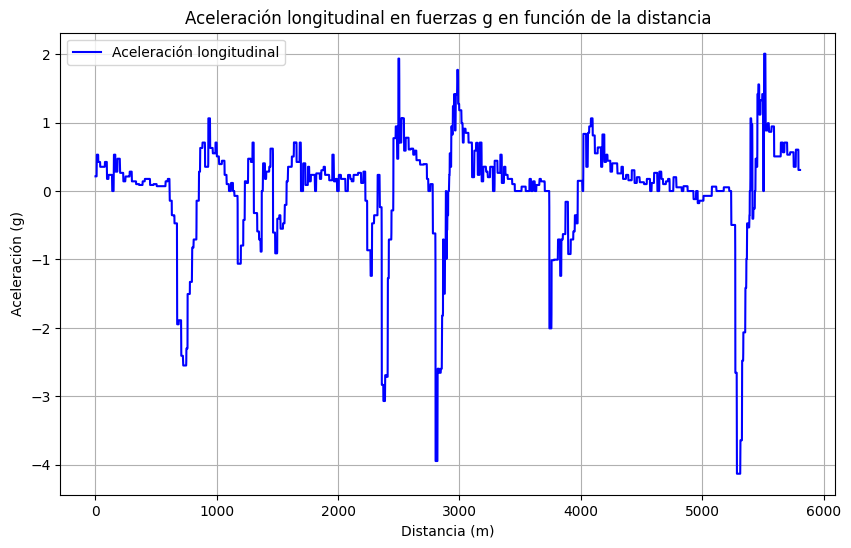

      Distance       Speed       Time  nGear      RPM  Throttle  Brake  \
0          0.0  279.000000   0.000000      7  11077.0     100.0    0.0   
1          1.0  279.097162   0.012825      7  11077.0     100.0    0.0   
2          2.0  279.194323   0.025651      7  11077.0     100.0    0.0   
3          3.0  279.291485   0.038476      7  11077.0     100.0    0.0   
4          4.0  279.388647   0.051301      7  11077.0     100.0    0.0   
...        ...         ...        ...    ...      ...       ...    ...   
5802    5802.0  277.667491  89.034409      7      NaN     100.0    0.0   
5803    5803.0  277.733993  89.040527      7      NaN     100.0    0.0   
5804    5804.0  277.800495  89.046646      7      NaN     100.0    0.0   
5805    5805.0  277.866997  89.052764      7      NaN     100.0    0.0   
5806    5806.0  277.933498  89.058882      7      NaN     100.0    0.0   

       speed_ms   delta_v   delta_t  acceleration_ms2  acceleration_g  
0     77.500000       NaN       NaN    

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Ejemplo de dataframe (reemplaza con tu data real)
data = {
    'speed': [300, 301, 302, 303, 304],  # km/h
    'distance': [1000, 1001, 1002, 1003, 1004],  # metros
    'time': [30.000, 30.033, 30.066, 30.099, 30.132]  # segundos
}
df = fl1_tel_interpolated.copy()

# Convertir velocidad de km/h a m/s
df['speed_ms'] = df['Speed'] * (5 / 18)

# Calcular diferencias (Delta v y Delta t)
df['delta_v'] = df['speed_ms'].diff()  # Diferencia de velocidad
df['delta_t'] = df['Time'].diff()      # Diferencia de tiempo

# Calcular aceleración en m/s²
df['acceleration_ms2'] = df['delta_v'] / df['delta_t']

# Convertir aceleración a fuerzas g (1 g = 9.81 m/s²)
df['acceleration_g'] = df['acceleration_ms2'] / 9.81

# Graficar aceleración en g vs distancia
plt.figure(figsize=(10, 6))
plt.plot(df['Distance'], df['acceleration_g'], label='Aceleración longitudinal', color='blue')
plt.xlabel('Distancia (m)')
plt.ylabel('Aceleración (g)')
plt.title('Aceleración longitudinal en fuerzas g en función de la distancia')
plt.grid(True)
plt.legend()
plt.show()

# Mostrar dataframe (opcional)
print(df)

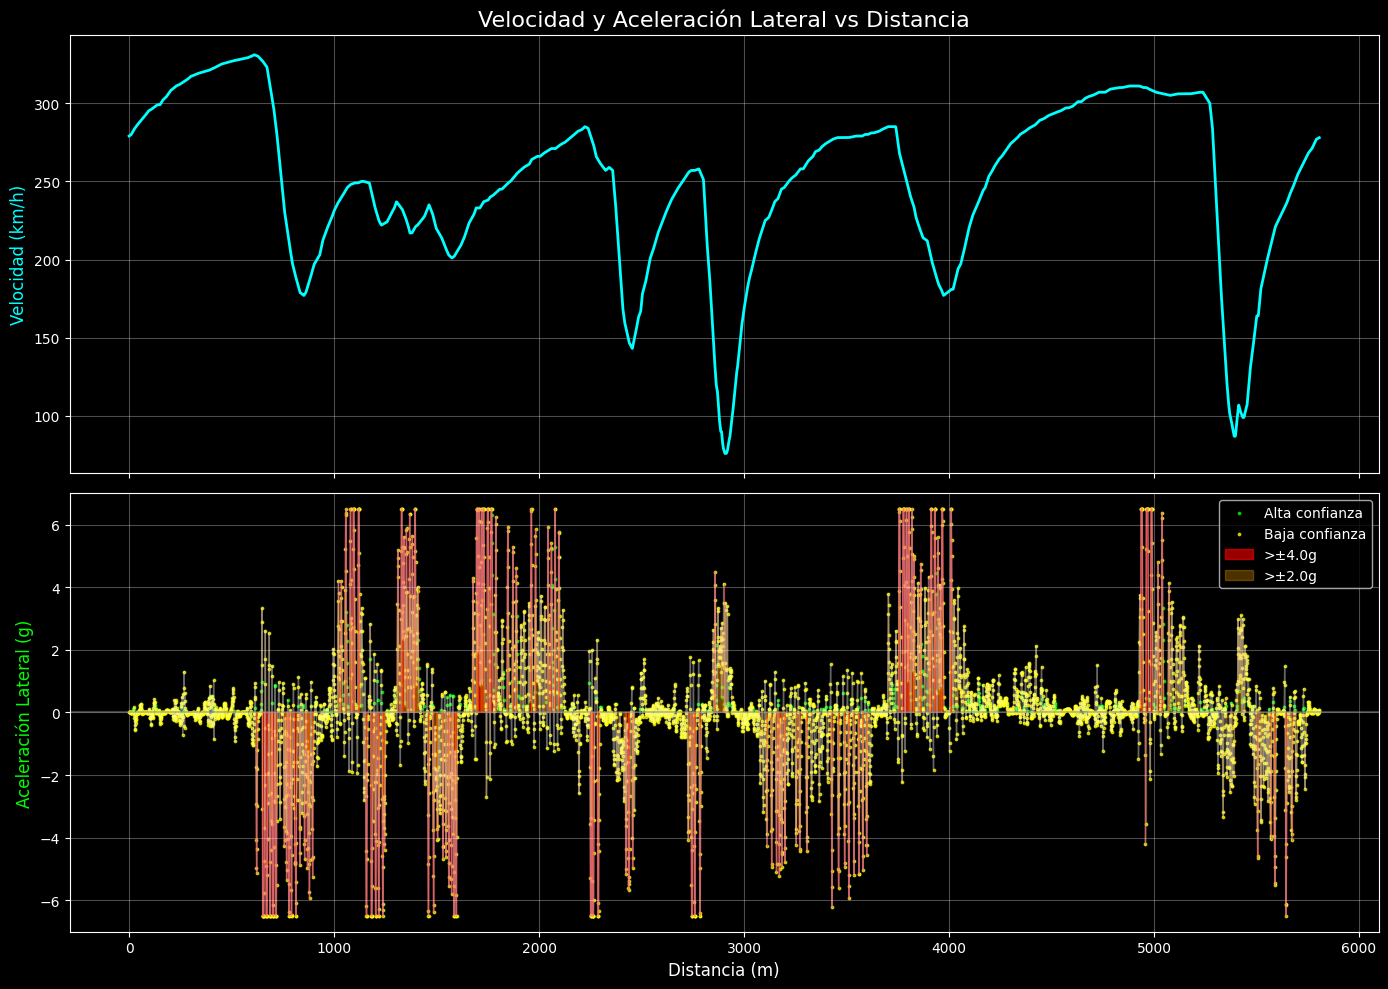


Estadísticas de Aceleración Lateral:
Máxima aceleración lateral: 22.62g
Mínima aceleración lateral: -21.26g
Aceleración lateral media (valor absoluto): 1.26g
Tiempo por encima de 2g: 20.2% de la vuelta


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

def align_telemetry_with_position(tel_data, pos_data, time_col='Time', 
                                 pos_cols=['X', 'Y'], interp_method='linear', 
                                 extrapolate=True, verbose=False):
    """
    Alinea datos de telemetría con datos de posición interpolando las columnas de posición 
    basadas en el tiempo.
    
    Args:
        tel_data (pd.DataFrame): DataFrame con datos de telemetría (velocidad, etc.).
        pos_data (pd.DataFrame): DataFrame con datos de posición (X, Y, etc.).
        time_col (str): Nombre de la columna de tiempo (default: 'Time').
        pos_cols (list): Lista de columnas de posición a interpolar (default: ['X', 'Y']).
        interp_method (str): Método de interpolación ('linear', 'cubic', etc.) (default: 'linear').
        extrapolate (bool): Si True, permite extrapolación; si False, usa NaN fuera de límites (default: True).
        verbose (bool): Si True, imprime información de depuración (default: False).
        
    Returns:
        pd.DataFrame: DataFrame combinado con datos de telemetría y posiciones interpoladas.
    """
    # Copiar los dataframes para no modificar los originales
    tel_df = tel_data.copy()
    pos_df = pos_data.copy()

    # Validar que las columnas necesarias estén presentes
    if time_col not in tel_df.columns or time_col not in pos_df.columns:
        raise ValueError(f"La columna '{time_col}' no está presente en uno de los DataFrames.")
    for col in pos_cols:
        if col not in pos_df.columns:
            raise ValueError(f"La columna '{col}' no está en pos_data.")

    # Convertir la columna de tiempo a segundos si es necesario
    def convert_to_seconds(df, col):
        if not pd.api.types.is_numeric_dtype(df[col]):
            if isinstance(df[col].iloc[0], pd.Timedelta):
                return df[col].dt.total_seconds()
            elif pd.api.types.is_datetime64_any_dtype(df[col]):
                # Si es datetime, convertir a segundos desde el inicio
                return (df[col] - df[col].min()).dt.total_seconds()
            else:
                raise ValueError(f"No se puede convertir '{col}' a formato numérico en {df[col].dtype}.")
        return df[col]

    tel_df[time_col] = convert_to_seconds(tel_df, time_col)
    pos_df[time_col] = convert_to_seconds(pos_df, time_col)

    # Ordenar ambos DataFrames por tiempo para asegurar interpolación correcta
    tel_df = tel_df.sort_values(time_col).reset_index(drop=True)
    pos_df = pos_df.sort_values(time_col).reset_index(drop=True)

    # Verificar si hay datos suficientes para interpolar
    if len(pos_df) < 2:
        raise ValueError("pos_data debe tener al menos 2 filas para interpolar.")

    # Crear funciones de interpolación para cada columna de posición
    interp_funcs = {}
    for col in pos_cols:
        if extrapolate:
            fill_value = 'extrapolate'
        else:
            fill_value = (pos_df[col].iloc[0], pos_df[col].iloc[-1])  # Límites para no extrapolar
        interp_funcs[col] = interp1d(
            pos_df[time_col], pos_df[col],
            kind=interp_method,
            bounds_error=False,
            fill_value=fill_value
        )

    # Agregar columnas interpoladas al DataFrame de telemetría
    for col in pos_cols:
        tel_df[col] = interp_funcs[col](tel_df[time_col])

    # Opcional: Imprimir información de depuración
    if verbose:
        print(f"Rango de tiempo en tel_data: {tel_df[time_col].min()} - {tel_df[time_col].max()}")
        print(f"Rango de tiempo en pos_data: {pos_df[time_col].min()} - {pos_df[time_col].max()}")
        print(f"Filas en tel_data: {len(tel_df)}, Filas en pos_data: {len(pos_df)}")

    return tel_df

# Ejemplo de uso:
# tel_data = pd.DataFrame({'Time': [0, 1, 2], 'Speed': [100, 110, 120]})
# pos_data = pd.DataFrame({'Time': [0, 1.5, 3], 'X': [0, 10, 20], 'Y': [0, 5, 15]})
# aligned_df = align_telemetry_with_position(tel_data, pos_data, verbose=True)



def preprocess_telemetry_data(df, position_cols=['X', 'Y'], time_col='Time', window=15):
    """Pre-procesa los datos de telemetría para eliminar ruido y valores atípicos."""
    df_clean = df.copy()
    
    # Filtro de mediana para eliminar valores atípicos en posición
    for col in position_cols:
        df_clean[f'{col}_median'] = df_clean[col].rolling(window=5, center=True).median()
    
    # Identificar y corregir saltos de tiempo anormales
    df_clean['dt'] = df_clean[time_col].diff()
    median_dt = df_clean['dt'].median()
    mask = df_clean['dt'] > 5 * median_dt
    
    # Interpolar valores donde hay saltos temporales grandes
    if mask.any():
        df_clean = df_clean[~mask].copy()
    
    return df_clean

def get_adaptive_window_size(speed_kph):
    """
    Returns an appropriate window size based on vehicle speed.
    Smaller windows for low speeds (tight corners) and larger windows for high speeds (straights).
    
    Args:
        speed_kph: Speed in kilometers per hour
        
    Returns:
        int: Window size for smoothing operations
    """
    base_window = 11
    if speed_kph < 80:  # Slow corners
        return max(5, base_window - 6)
    elif speed_kph < 150:  # Medium-speed sections
        return base_window
    else:  # High-speed sections and straights
        return base_window + 6
def calculate_advanced_lateral_acceleration(df, position_cols=['X', 'Y'], time_col='Time', 
                                           speed_col='Speed', window_size=21):
    # [existing code...]
    
    # Create array to store adaptive window sizes for each data point
    adaptive_windows = np.zeros(len(result_df), dtype=int)
    
    # Calculate appropriate window size for each point based on speed
    for i in range(len(result_df)):
        adaptive_windows[i] = get_adaptive_window_size(result_df[speed_col].iloc[i])
    
    # Ensure all window sizes are odd (required for Savitzky-Golay filter)
    adaptive_windows = (adaptive_windows // 2) * 2 + 1
    
    # Apply window size limits
    adaptive_windows = np.clip(adaptive_windows, 5, min(21, len(df) - 2))
    
    # Store the window sizes for reference
    result_df['adaptive_window'] = adaptive_windows
    
    # [existing code for initial smoothing...]
    
    # Apply segment-by-segment smoothing with adaptive windows
    smooth_data = np.copy(result_df['heading_diff'].fillna(0).values)
    
    for i in range(len(smooth_data)):
        # Get window size for this point
        win_size = adaptive_windows[i]
        
        # Calculate half window size
        half_win = win_size // 2
        
        # Handle edge cases
        if i < half_win:
            # Near the start
            start_idx = 0
            end_idx = min(win_size, len(smooth_data))
        elif i >= len(smooth_data) - half_win:
            # Near the end
            start_idx = max(0, len(smooth_data) - win_size)
            end_idx = len(smooth_data)
        else:
            # Normal case
            start_idx = i - half_win
            end_idx = i + half_win + 1
            
        # Apply local smoothing if we have enough points
        if end_idx - start_idx >= 5:
            # For this segment, apply Savitzky-Golay filter if window is large enough
            if end_idx - start_idx >= 5:
                segment = smooth_data[start_idx:end_idx]
                # We need odd window and window < segment length
                sg_window = min(win_size, (end_idx - start_idx) // 2 * 2 + 1)
                if sg_window >= 5:
                    smooth_segment = savgol_filter(segment, sg_window, 3)
                    # Only update the center point
                    if i - start_idx < len(smooth_segment):
                        smooth_data[i] = smooth_segment[i - start_idx]
    
    result_df['angular_velocity'] = smooth_data
    
    # 6. Usar estimación múltiple y promediado para la aceleración lateral
    # Método 1: v * ω (velocidad lineal * velocidad angular)
    method1 = result_df['Speed_smooth'] * result_df['angular_velocity']
    
    # Método 2: basado en curvatura
    speed_squared = result_df['Speed_smooth']**2
    dx_squared = result_df['dx']**2
    dy_squared = result_df['dy']**2
    
    # Segunda derivada usando diferencias finitas (con más suavizado)
    ddx = savgol_filter(np.gradient(result_df['dx'].values, result_df[time_col].values), window_size, 3)
    ddy = savgol_filter(np.gradient(result_df['dy'].values, result_df[time_col].values), window_size, 3)
    
    # Fórmula de curvatura κ = |x'y'' - y'x''| / (x'^2 + y'^2)^(3/2)
    numerator = np.abs(result_df['dx'].values * ddy - result_df['dy'].values * ddx)
    denominator = (dx_squared + dy_squared)**1.5
    safe_denom = np.where(denominator > 1e-10, denominator, 1e-10)  # Evitar división por cero
    method2 = speed_squared * (numerator / safe_denom)
    
    # Promediar los dos métodos con pesos
    lateral_acc_ms2 = 0.6 * method1 + 0.4 * method2
    
    # 7. Convertir a G y aplicar límites físicos realistas
    result_df['lateral_acceleration_ms2'] = lateral_acc_ms2
    result_df['lateral_acceleration_g'] = lateral_acc_ms2 / 9.81
    
    # 8. Filtro final para eliminar picos remanentes
    smooth_data = np.copy(result_df['lateral_acceleration_g'].fillna(0).values)
    for i in range(len(smooth_data)):
        win_size = adaptive_windows[i]
        # [Apply local smoothing as shown above]
    result_df['lateral_acceleration_g_smooth'] = smooth_data
    
    # 9. Aplicar restricciones físicas basadas en el rendimiento de F1 (~6G es realista para F1 moderno)
    max_g_force = 6.5
    result_df['lateral_acceleration_g_final'] = result_df['lateral_acceleration_g_smooth'].clip(-max_g_force, max_g_force)
    
    # 10. Identificar y marcar regiones de baja confianza
    result_df['low_confidence'] = (np.abs(method1 - method2) > 0.5 * np.abs(method1 + method2))
    
    return result_df

# Paso 3: Visualizar los resultados
def plot_improved_lateral_acceleration(df, distance_col='Distance'):
    """
    Visualiza la aceleración lateral con indicadores de confianza y áreas de alta aceleración.
    """
    plt.style.use('dark_background')
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Gráfico de velocidad
    ax1.plot(df[distance_col], df['Speed'], color='cyan', linewidth=2)
    ax1.set_ylabel('Velocidad (km/h)', color='cyan', fontsize=12)
    ax1.set_title('Velocidad y Aceleración Lateral vs Distancia', fontsize=16)
    ax1.grid(True, alpha=0.3)
    
    # Gráfico de aceleración lateral con indicador de confianza
    accel_color = np.where(df.get('low_confidence', False), 'yellow', 'lime')
    
    # Usar scatter para indicar la confianza mediante el color
    for i, confidence in enumerate(['high', 'low']):
        mask = df.get('low_confidence', False) == (confidence == 'low')
        if mask.any():
            color = 'yellow' if confidence == 'low' else 'lime'
            label = 'Baja confianza' if confidence == 'low' else 'Alta confianza'
            ax2.scatter(
                df.loc[mask, distance_col], 
                df.loc[mask, 'lateral_acceleration_g_final'],
                color=color, s=3, alpha=0.7, label=label
            )
    
    # Línea continua para la aceleración
    ax2.plot(df[distance_col], df['lateral_acceleration_g_final'], color='white', linewidth=1, alpha=0.4)
    ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    
    # Sombrear áreas de alta aceleración lateral
    threshold_high = 4.0  # 4g como umbral para curvas muy exigentes
    threshold_med = 2.0   # 2g como umbral para curvas exigentes
    
    high_g_mask = abs(df['lateral_acceleration_g_final']) > threshold_high
    med_g_mask = (abs(df['lateral_acceleration_g_final']) > threshold_med) & (abs(df['lateral_acceleration_g_final']) <= threshold_high)
    
    if high_g_mask.any():
        ax2.fill_between(
            df[distance_col], 
            df['lateral_acceleration_g_final'],
            0, 
            where=high_g_mask,
            color='red', 
            alpha=0.6,
            label=f'>±{threshold_high}g'
        )
    
    if med_g_mask.any():
        ax2.fill_between(
            df[distance_col], 
            df['lateral_acceleration_g_final'],
            0, 
            where=med_g_mask,
            color='orange', 
            alpha=0.3,
            label=f'>±{threshold_med}g'
        )
    
    # Configurar ejes
    ax2.set_xlabel('Distancia (m)', fontsize=12)
    ax2.set_ylabel('Aceleración Lateral (g)', color='lime', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')
    
    # Establecer límites verticales apropiados para mostrar claramente las aceleraciones
    ax2.set_ylim(-7, 7)
    
    plt.tight_layout()
    plt.show()


def remove_acceleration_spikes(df, acc_col='lateral_acceleration_g_smooth', window=7, threshold=2.5):
    """
    Detecta y elimina picos irreales en aceleración, reemplazándolos con valores interpolados.
    """
    result = df.copy()
    
    # Calcular media móvil y desviación estándar
    rolling_mean = result[acc_col].rolling(window=window, center=True).mean()
    rolling_std = result[acc_col].rolling(window=window, center=True).std()
    
    # Identificar valores que se desvían demasiado
    outliers = np.abs(result[acc_col] - rolling_mean) > (threshold * rolling_std)
    
    # Reemplazar valores atípicos con NaN y luego interpolar
    result.loc[outliers, acc_col] = np.nan
    result[acc_col] = result[acc_col].interpolate(method='cubic')
    
    return result


# Ejecutar todo el proceso
try:
    # 1. Alinear los dataframes
    combined_df = align_telemetry_with_position(fl1_tel_interpolated, fl1_tel_xy)
    combined_df = preprocess_telemetry_data(combined_df)
    
    # 2. Calcular la aceleración lateral
    result_df = calculate_advanced_lateral_acceleration(combined_df)
    result_df = remove_acceleration_spikes(result_df)
    # 3. Visualizar los resultados
    plot_improved_lateral_acceleration(result_df)
    
    # Mostrar estadísticas de aceleración lateral
    print("\nEstadísticas de Aceleración Lateral:")
    print(f"Máxima aceleración lateral: {result_df['lateral_acceleration_g_smooth'].max():.2f}g")
    print(f"Mínima aceleración lateral: {result_df['lateral_acceleration_g_smooth'].min():.2f}g")
    print(f"Aceleración lateral media (valor absoluto): {result_df['lateral_acceleration_g_smooth'].abs().mean():.2f}g")
    print(f"Tiempo por encima de 2g: {100 * (abs(result_df['lateral_acceleration_g_smooth']) > 2).mean():.1f}% de la vuelta")
    
except Exception as e:
    print(f"Error al procesar los datos: {e}")

In [91]:
combined_df

,Distance,Speed,Time,nGear,RPM,Throttle,Brake,X,Y
0,0.0,281.000000,0.000000,7,11210.0,100.0,0.0,1607.731343,-541.104478
1,1.0,281.120225,0.012744,7,11210.0,100.0,0.0,1614.261755,-548.712725
2,2.0,281.240449,0.025488,7,11210.0,100.0,0.0,1620.792167,-556.320972
3,3.0,281.360674,0.038231,7,11210.0,100.0,0.0,1627.322579,-563.929219
4,4.0,281.480899,0.050975,7,11210.0,100.0,0.0,1633.852991,-571.537466
...,...,...,...,...,...,...,...,...,...
5802,5802.0,275.667245,86.930757,7,NaN,100.0,0.0,1686.218541,-633.369571
5803,5803.0,275.733796,86.941206,7,NaN,100.0,0.0,1694.697910,-643.295657
5804,5804.0,275.800347,86.951654,7,NaN,100.0,0.0,1703.177278,-653.221743
5805,5805.0,275.866898,86.962103,7,NaN,100.0,0.0,1711.656647,-663.147829


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Supongamos que tu DataFrame se llama 'df'
# df = pd.read_csv('tu_archivo.csv')  # Si lo lees de un archivo

# Suavizar las coordenadas X e Y con una ventana más amplia (10 puntos)
df['X_smooth'] = df['X'].rolling(window=10, center=True).mean()
df['Y_smooth'] = df['Y'].rolling(window=10, center=True).mean()

# Convertir velocidad de km/h a m/s
df['Speed_ms'] = df['Speed'] * 1000 / 3600  # Nueva columna en m/s

# Calcular las derivadas usando diferencias finitas con datos suavizados
df['dt'] = df['Time'].diff()  # Diferencia de tiempo en segundos
df['dx'] = df['X_smooth'].diff() / df['dt']  # Velocidad en x (m/s)
df['dy'] = df['Y_smooth'].diff() / df['dt']  # Velocidad en y (m/s)

# Segundas derivadas (aceleración en x e y)
df['ddx'] = df['dx'].diff() / df['dt']  # Aceleración en x (m/s²)
df['ddy'] = df['dy'].diff() / df['dt']  # Aceleración en y (m/s²)

# Curvatura (kappa)
numerator = np.abs(df['dx'] * df['ddy'] - df['dy'] * df['ddx'])
denominator = (df['dx']**2 + df['dy']**2)**1.5
df['kappa'] = numerator / denominator

# Radio de curvatura (R = 1/kappa)
df['R'] = 1 / df['kappa']

# Aceleración lateral en m/s²
df['Lateral_Acc_ms2'] = df['Speed_ms']**2 / df['R']

# Convertir a fuerzas g (1 g = 9.81 m/s²)
df['Lateral_Acc_g'] = df['Lateral_Acc_ms2'] / 9.81

# Limitar valores a un máximo físico razonable (6.5 g)
df['Lateral_Acc_g'] = df['Lateral_Acc_g'].clip(lower=-10, upper=10)

# Limpiar valores NaN o infinitos
df = df.dropna()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Inspeccionar valores máximos y mínimos
print("Máxima aceleración lateral (g):", df['Lateral_Acc_g'].max())
print("Mínima aceleración lateral (g):", df['Lateral_Acc_g'].min())

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(df['Distance'], df['Lateral_Acc_g'], label='Aceleración Lateral (g)')
plt.xlabel('Distancia (m)')
plt.ylabel('Aceleración Lateral (g)')
plt.title('Aceleración Lateral a lo largo de la pista')
plt.grid(True)
plt.legend()
plt.ylim(-7, 7)  # Establecer límites en el eje y para visualizar mejor
plt.show()

KeyError: 'X'

C:\Users\Danie\AppData\Local\Temp\ipykernel_13544\2525372422.py:115: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

C:\Users\Danie\AppData\Local\Temp\ipykernel_13544\2525372422.py:117: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



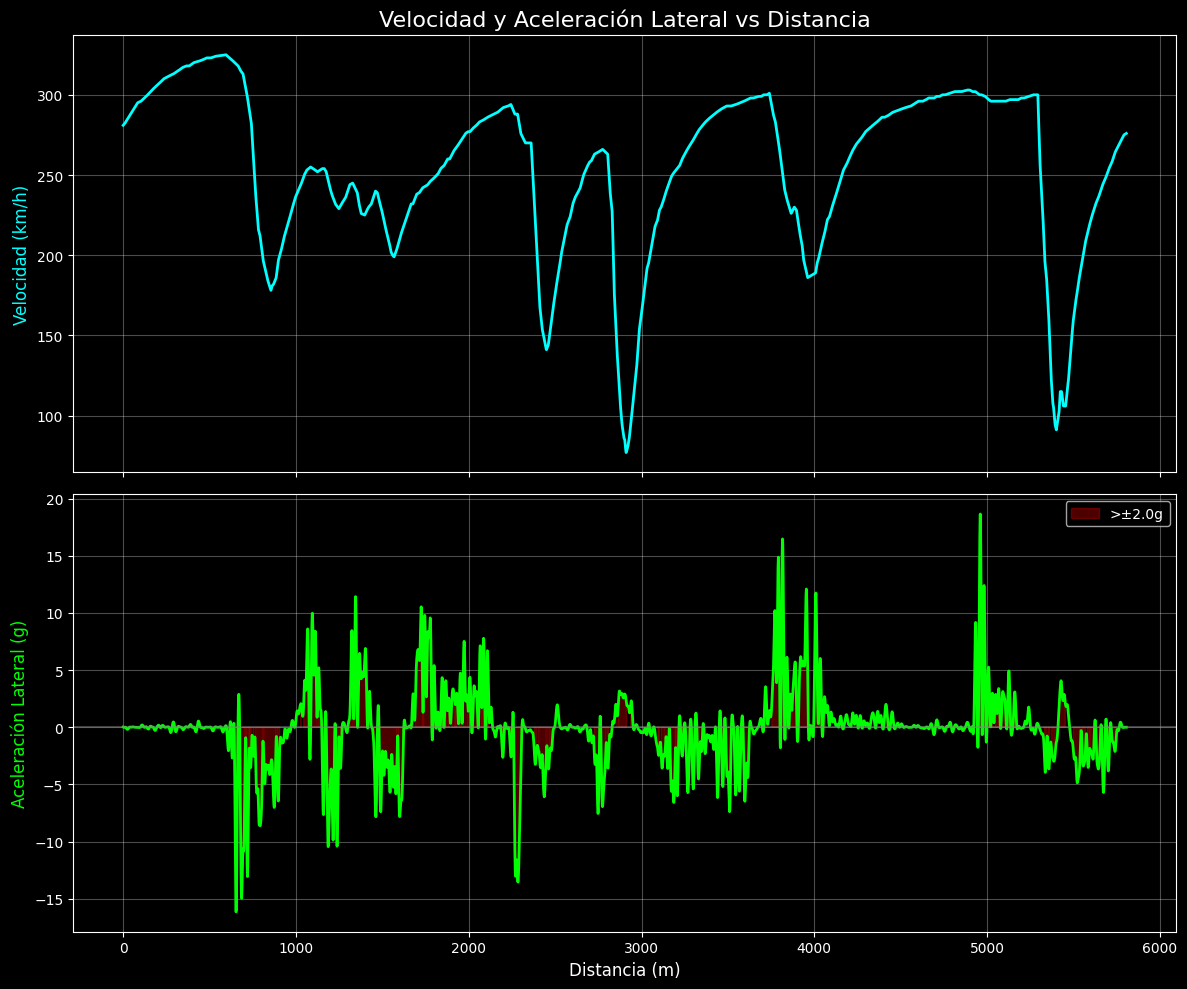

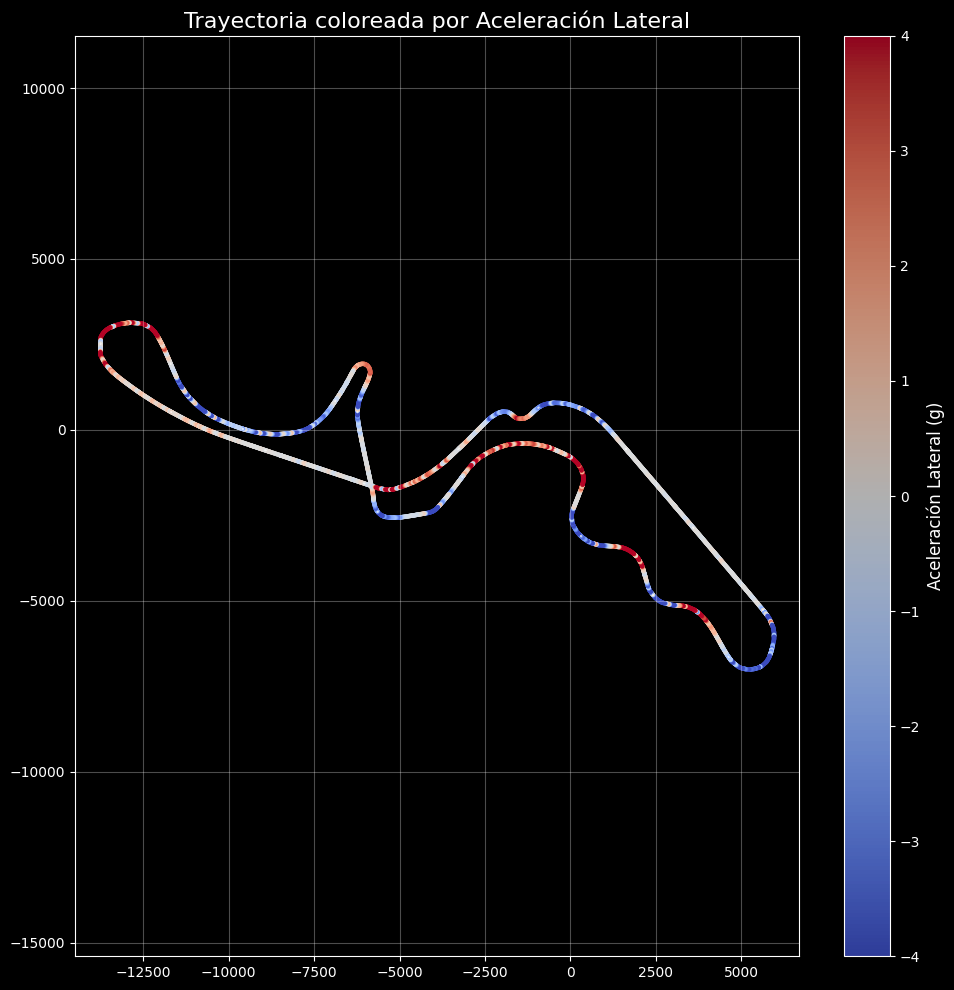


Estadísticas de Aceleración Lateral:
Máxima aceleración lateral: 18.66g
Mínima aceleración lateral: -16.15g
Aceleración lateral media (valor absoluto): 2.05g
Tiempo por encima de 2g: 35.1% de la vuelta


In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

def align_telemetry_with_position(tel_data, pos_data, time_col='Time', 
                                 pos_cols=['X', 'Y'], interp_method='linear', 
                                 extrapolate=True, verbose=False):
    """
    Alinea datos de telemetría con datos de posición interpolando las columnas de posición 
    basadas en el tiempo.
    
    Args:
        tel_data (pd.DataFrame): DataFrame con datos de telemetría (velocidad, etc.).
        pos_data (pd.DataFrame): DataFrame con datos de posición (X, Y, etc.).
        time_col (str): Nombre de la columna de tiempo (default: 'Time').
        pos_cols (list): Lista de columnas de posición a interpolar (default: ['X', 'Y']).
        interp_method (str): Método de interpolación ('linear', 'cubic', etc.) (default: 'linear').
        extrapolate (bool): Si True, permite extrapolación; si False, usa NaN fuera de límites (default: True).
        verbose (bool): Si True, imprime información de depuración (default: False).
        
    Returns:
        pd.DataFrame: DataFrame combinado con datos de telemetría y posiciones interpoladas.
    """
    # Copiar los dataframes para no modificar los originales
    tel_df = tel_data.copy()
    pos_df = pos_data.copy()

    # Validar que las columnas necesarias estén presentes
    if time_col not in tel_df.columns or time_col not in pos_df.columns:
        raise ValueError(f"La columna '{time_col}' no está presente en uno de los DataFrames.")
    for col in pos_cols:
        if col not in pos_df.columns:
            raise ValueError(f"La columna '{col}' no está en pos_data.")

    # Convertir la columna de tiempo a segundos si es necesario
    def convert_to_seconds(df, col):
        if not pd.api.types.is_numeric_dtype(df[col]):
            if isinstance(df[col].iloc[0], pd.Timedelta):
                return df[col].dt.total_seconds()
            elif pd.api.types.is_datetime64_any_dtype(df[col]):
                # Si es datetime, convertir a segundos desde el inicio
                return (df[col] - df[col].min()).dt.total_seconds()
            else:
                raise ValueError(f"No se puede convertir '{col}' a formato numérico en {df[col].dtype}.")
        return df[col]

    tel_df[time_col] = convert_to_seconds(tel_df, time_col)
    pos_df[time_col] = convert_to_seconds(pos_df, time_col)

    # Ordenar ambos DataFrames por tiempo para asegurar interpolación correcta
    tel_df = tel_df.sort_values(time_col).reset_index(drop=True)
    pos_df = pos_df.sort_values(time_col).reset_index(drop=True)

    # Verificar si hay datos suficientes para interpolar
    if len(pos_df) < 2:
        raise ValueError("pos_data debe tener al menos 2 filas para interpolar.")

    # Crear funciones de interpolación para cada columna de posición
    interp_funcs = {}
    for col in pos_cols:
        if extrapolate:
            fill_value = 'extrapolate'
        else:
            fill_value = (pos_df[col].iloc[0], pos_df[col].iloc[-1])  # Límites para no extrapolar
        interp_funcs[col] = interp1d(
            pos_df[time_col], pos_df[col],
            kind=interp_method,
            bounds_error=False,
            fill_value=fill_value
        )

    # Agregar columnas interpoladas al DataFrame de telemetría
    for col in pos_cols:
        tel_df[col] = interp_funcs[col](tel_df[time_col])

    # Opcional: Imprimir información de depuración
    if verbose:
        print(f"Rango de tiempo en tel_data: {tel_df[time_col].min()} - {tel_df[time_col].max()}")
        print(f"Rango de tiempo en pos_data: {pos_df[time_col].min()} - {pos_df[time_col].max()}")
        print(f"Filas en tel_data: {len(tel_df)}, Filas en pos_data: {len(pos_df)}")

    return tel_df

# Ejemplo de uso:
# tel_data = pd.DataFrame({'Time': [0, 1, 2], 'Speed': [100, 110, 120]})
# pos_data = pd.DataFrame({'Time': [0, 1.5, 3], 'X': [0, 10, 20], 'Y': [0, 5, 15]})
# aligned_df = align_telemetry_with_position(tel_data, pos_data, verbose=True)

# Paso 2: Calcular la aceleración lateral
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

def calculate_smooth_lateral_acceleration(df, position_cols=['X', 'Y'], time_col='Time', 
                                         speed_col='Speed', window_size=21):
    """
    Calculate lateral acceleration with improved smoothing to avoid spikes.
    """
    # Create a copy to avoid modifying the original
    result_df = df.copy()
    
    # Make sure window size is odd (required for Savitzky-Golay)
    if window_size % 2 == 0:
        window_size += 1
    window_size = min(window_size, len(df) - 2)  # Ensure window isn't too large
    
    # Step 1: Apply Savitzky-Golay smoothing to position data before differentiation
    result_df['X_smooth'] = savgol_filter(df['X'].fillna(method='ffill').fillna(method='bfill'),
                                        window_size, 3)
    result_df['Y_smooth'] = savgol_filter(df['Y'].fillna(method='ffill').fillna(method='bfill'), 
                                        window_size, 3)
    
    # Step 2: Convert speed to m/s
    result_df['Speed_ms'] = result_df[speed_col] * (1000 / 3600)
    
    # Step 3: Calculate time differences with smoother method
    result_df['dt'] = result_df[time_col].diff()
    result_df.loc[result_df['dt'] <= 0, 'dt'] = result_df['dt'].median()  # Handle zero/negative time diffs
    
    # Step 4: Calculate velocities using centered differences when possible
    n = len(result_df)
    dx = np.zeros(n)
    dy = np.zeros(n)
    
    # Use centered differences for internal points, forward/backward for endpoints
    for i in range(1, n-1):
        dx[i] = (result_df['X_smooth'].iloc[i+1] - result_df['X_smooth'].iloc[i-1]) / \
                (result_df[time_col].iloc[i+1] - result_df[time_col].iloc[i-1])
        dy[i] = (result_df['Y_smooth'].iloc[i+1] - result_df['Y_smooth'].iloc[i-1]) / \
                (result_df[time_col].iloc[i+1] - result_df[time_col].iloc[i-1])
    
    # Handle endpoints
    if n > 1:
        dx[0] = (result_df['X_smooth'].iloc[1] - result_df['X_smooth'].iloc[0]) / \
                (result_df[time_col].iloc[1] - result_df[time_col].iloc[0])
        dy[0] = (result_df['Y_smooth'].iloc[1] - result_df['Y_smooth'].iloc[0]) / \
                (result_df[time_col].iloc[1] - result_df[time_col].iloc[0])
        dx[n-1] = (result_df['X_smooth'].iloc[n-1] - result_df['X_smooth'].iloc[n-2]) / \
                 (result_df[time_col].iloc[n-1] - result_df[time_col].iloc[n-2])
        dy[n-1] = (result_df['Y_smooth'].iloc[n-1] - result_df['Y_smooth'].iloc[n-2]) / \
                 (result_df[time_col].iloc[n-1] - result_df[time_col].iloc[n-2])
    
    result_df['dx'] = dx
    result_df['dy'] = dy
    
    # Step 5: Calculate heading (direction of travel)
    result_df['heading'] = np.arctan2(result_df['dy'], result_df['dx'])
    
    # Step 6: Unwrap heading to avoid discontinuities at ±π
    result_df['heading_unwrapped'] = np.unwrap(result_df['heading'])
    
    # Step 7: Calculate heading change rate (angular velocity) using smoothed differences
    result_df['heading_diff'] = result_df['heading_unwrapped'].diff()
    result_df['angular_velocity'] = savgol_filter(
        result_df['heading_diff'].fillna(0) / result_df['dt'].fillna(result_df['dt'].median()),
        window_size, 3
    )
    
    # Step 8: Calculate lateral acceleration (v * ω)
    result_df['lateral_acceleration_ms2'] = result_df['Speed_ms'] * result_df['angular_velocity']
    
    # Step 9: Convert to G forces and apply final smoothing
    result_df['lateral_acceleration_g'] = result_df['lateral_acceleration_ms2'] / 9.81
    result_df['lateral_acceleration_g_smooth'] = savgol_filter(
        result_df['lateral_acceleration_g'].fillna(0), 
        window_size, 3
    )
    
    # Step 10: Remove physically impossible values
    max_g = 6.0  # F1 cars typically don't exceed 6G laterally
    result_df['lateral_acceleration_g_final'] = result_df['lateral_acceleration_g_smooth'].clip(-max_g, max_g)
    
    return result_df
# Paso 3: Visualizar los resultados
def plot_lateral_acceleration(df, distance_col='Distance'):
    """
    Genera gráficos para visualizar la aceleración lateral.
    
    Args:
        df: DataFrame con los datos procesados
        distance_col: Nombre de la columna con la distancia
    """
    # Configurar el estilo del gráfico
    plt.style.use('dark_background')
    
    # Crear una figura de 2 subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Graficar velocidad vs distancia
    ax1.plot(df[distance_col], df['Speed'], color='cyan', linewidth=2)
    ax1.set_ylabel('Velocidad (km/h)', color='cyan', fontsize=12)
    ax1.set_title('Velocidad y Aceleración Lateral vs Distancia', fontsize=16)
    ax1.grid(True, alpha=0.3)
    
    # Agregar un segundo eje Y para la aceleración lateral
    ax2.plot(df[distance_col], df['lateral_acceleration_g_smooth'], color='lime', linewidth=2)
    ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    
    # Sombrear áreas de alta aceleración lateral
    threshold = 2.0  # 2g como umbral para curvas exigentes
    high_g_mask = abs(df['lateral_acceleration_g_smooth']) > threshold
    
    if high_g_mask.any():
        ax2.fill_between(
            df[distance_col], 
            df['lateral_acceleration_g_smooth'],
            0, 
            where=high_g_mask,
            color='red', 
            alpha=0.3,
            label=f'>±{threshold}g'
        )
    
    # Configurar ejes
    ax2.set_xlabel('Distancia (m)', fontsize=12)
    ax2.set_ylabel('Aceleración Lateral (g)', color='lime', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Ajustar el layout
    plt.tight_layout()
    
    # Crear un segundo gráfico: la trayectoria con colores basados en G laterales
    plt.figure(figsize=(10, 10))
    
    # Usar scatter para colorear según la aceleración lateral
    scatter = plt.scatter(
        df['X'], df['Y'],
        c=df['lateral_acceleration_g_smooth'],
        cmap='coolwarm', 
        vmin=-4, vmax=4,  # Limitar el rango de colores
        s=5,
        alpha=0.8
    )
    
    # Añadir una barra de colores
    cbar = plt.colorbar(scatter)
    cbar.set_label('Aceleración Lateral (g)', fontsize=12)
    
    # Configurar los ejes para mantener la escala correcta
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.title('Trayectoria coloreada por Aceleración Lateral', fontsize=16)
    
    # Mostrar el sentido de la marcha con flechas
    arrow_indices = np.linspace(0, len(df)-1, 20).astype(int)
    for i in arrow_indices:
        if i+1 < len(df):
            plt.arrow(
                df['X'].iloc[i], df['Y'].iloc[i],
                (df['X'].iloc[i+1] - df['X'].iloc[i])*3,  # Factor de escala para ver mejor
                (df['Y'].iloc[i+1] - df['Y'].iloc[i])*3,
                head_width=20, head_length=20, fc='white', ec='white', alpha=0.6
            )
    
    plt.tight_layout()
    plt.show()

# Ejecutar todo el proceso
try:
    # 1. Alinear los dataframes
    combined_df = align_telemetry_with_position(fl1_tel_interpolated, fl1_tel_xy)
    
    # 2. Calcular la aceleración lateral
    result_df = calculate_smooth_lateral_acceleration(combined_df)
    
    # 3. Visualizar los resultados
    plot_lateral_acceleration(result_df)
    
    # Mostrar estadísticas de aceleración lateral
    print("\nEstadísticas de Aceleración Lateral:")
    print(f"Máxima aceleración lateral: {result_df['lateral_acceleration_g_smooth'].max():.2f}g")
    print(f"Mínima aceleración lateral: {result_df['lateral_acceleration_g_smooth'].min():.2f}g")
    print(f"Aceleración lateral media (valor absoluto): {result_df['lateral_acceleration_g_smooth'].abs().mean():.2f}g")
    print(f"Tiempo por encima de 2g: {100 * (abs(result_df['lateral_acceleration_g_smooth']) > 2).mean():.1f}% de la vuelta")
    
except Exception as e:
    print(f"Error al procesar los datos: {e}")

Error al procesar los datos: process_lateral_acceleration() got an unexpected keyword argument 'time_col'


Traceback (most recent call last):
  File "C:\Users\Danie\AppData\Local\Temp\ipykernel_19840\2125603224.py", line 255, in <module>
    result_df = process_lateral_acceleration(fl1_tel_xy, fl1_tel_interpolated, time_col='Time')
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: process_lateral_acceleration() got an unexpected keyword argument 'time_col'


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

def merge_by_nearest_time(df_coords, df_telemetry, time_col='Time'):
    """
    Combina dos DataFrames basándose en los valores más cercanos de la columna 'Time'.
    Equivalente a un LEFT JOIN en SQL (conserva todas las filas de df_coords).
    
    Args:
        df_coords: DataFrame con coordenadas (menos filas)
        df_telemetry: DataFrame con telemetría (más filas)
        time_col: Nombre de la columna de tiempo
        
    Returns:
        DataFrame combinado con misma cantidad de filas que df_coords
    """
    # Asegurar que ambos estén ordenados por tiempo
    df_coords_sorted = df_coords.sort_values(by=time_col).reset_index(drop=True)
    df_telemetry_sorted = df_telemetry.sort_values(by=time_col).reset_index(drop=True)
    
    # Usar merge_asof para unir por el tiempo más cercano
    merged_df = pd.merge_asof(
        df_coords_sorted,
        df_telemetry_sorted,
        on=time_col,
        direction='nearest',
        tolerance=None  # Sin límite de tolerancia
    )
    
    return merged_df

def calculate_lateral_acceleration(df, speed_col='Speed', radius_col='radio_curvatura'):
    """
    Calcula la aceleración lateral a partir de la velocidad y el radio de curvatura.
    
    Args:
        df: DataFrame con velocidad (km/h) y radio de curvatura (m)
        speed_col: Nombre de columna con velocidad
        radius_col: Nombre de columna con radio de curvatura
        
    Returns:
        DataFrame con columna adicional 'aceleracion_lateral_g'
    """
    result_df = df.copy()
    
    # Convertir velocidad de km/h a m/s
    speed_ms = result_df[speed_col] * (1000 / 3600)  # km/h a m/s
    
    # Evitar divisiones por cero y valores nulos
    with np.errstate(divide='ignore', invalid='ignore'):
        # Fórmula: a_lat = v²/r
        lateral_acc_ms2 = np.square(speed_ms) / result_df[radius_col]
        
        # Reemplazar infinitos y NaN por 0
        lateral_acc_ms2 = np.where(
            (np.isfinite(lateral_acc_ms2)) & (result_df[radius_col] != 0),
            lateral_acc_ms2,
            0
        )
    
    # Convertir a fuerzas G (1g = 9.81 m/s²)
    result_df['aceleracion_lateral_g'] = lateral_acc_ms2 / 9.81
    
    # Aplicar suavizado para eliminar picos irrealistas
    window_size = min(51, len(result_df) - 1)
    if window_size > 3 and window_size % 2 == 0:  # Asegurar que sea impar
        window_size -= 1
        
    if window_size >= 3:  # Necesitamos al menos 3 puntos para suavizar
        result_df['aceleracion_lateral_g_smooth'] = savgol_filter(
            result_df['aceleracion_lateral_g'], 
            window_size, 
            3  # Polinomio de orden 3
        )
    else:
        result_df['aceleracion_lateral_g_smooth'] = result_df['aceleracion_lateral_g']
    
    # Recortar valores extremos (límites físicos para un coche de F1)
    result_df['aceleracion_lateral_g_smooth'] = result_df['aceleracion_lateral_g_smooth'].clip(-6.0, 6.0)
    
    return result_df

def plot_lateral_g_vs_distance(df, distance_col='Distance', g_col='aceleracion_lateral_g_smooth'):
    """
    Crea un gráfico mejorado de fuerzas G laterales vs distancia.
    
    Args:
        df: DataFrame procesado
        distance_col: Nombre de la columna con distancia
        g_col: Nombre de la columna con fuerzas G
    """
    plt.figure(figsize=(14, 8))
    
    # Crear el gráfico principal
    plt.plot(df[distance_col], df[g_col], 'b-', linewidth=1.5)
    
    # Sombrear áreas según la magnitud de la aceleración lateral
    high_g_mask_pos = df[g_col] > 3.0  # Alto G positivo (derecha)
    high_g_mask_neg = df[g_col] < -3.0  # Alto G negativo (izquierda)
    med_g_mask_pos = (df[g_col] > 1.5) & (df[g_col] <= 3.0)  # Medio G positivo
    med_g_mask_neg = (df[g_col] < -1.5) & (df[g_col] >= -3.0)  # Medio G negativo
    
    # Sombrear cada categoría con colores distintos
    if high_g_mask_pos.any():
        plt.fill_between(
            df[distance_col], df[g_col], 0, 
            where=high_g_mask_pos,
            color='red', alpha=0.5, 
            label='Alta G (>3G) - Giro derecha'
        )
    
    if high_g_mask_neg.any():
        plt.fill_between(
            df[distance_col], df[g_col], 0, 
            where=high_g_mask_neg,
            color='blue', alpha=0.5, 
            label='Alta G (<-3G) - Giro izquierda'
        )
    
    if med_g_mask_pos.any():
        plt.fill_between(
            df[distance_col], df[g_col], 0, 
            where=med_g_mask_pos,
            color='orange', alpha=0.3, 
            label='Media G (1.5-3G) - Giro derecha'
        )
    
    if med_g_mask_neg.any():
        plt.fill_between(
            df[distance_col], df[g_col], 0, 
            where=med_g_mask_neg,
            color='lightblue', alpha=0.3, 
            label='Media G (-1.5 a -3G) - Giro izquierda'
        )
    
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Añadir líneas de referencia
    plt.axhline(y=3, color='red', linestyle='--', alpha=0.5)
    plt.axhline(y=-3, color='blue', linestyle='--', alpha=0.5)
    
    # Configurar el gráfico
    plt.title('Aceleración Lateral (G) vs Distancia', fontsize=16)
    plt.xlabel('Distancia (m)', fontsize=12)
    plt.ylabel('Aceleración Lateral (G)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.ylim(-6.5, 6.5)  # Límites realistas para F1
    
    # Añadir velocidad como línea secundaria
    ax2 = plt.gca().twinx()
    ax2.plot(df[distance_col], df['Speed'], 'g-', alpha=0.4, linewidth=1)
    ax2.set_ylabel('Velocidad (km/h)', color='g', fontsize=12)
    
    plt.tight_layout()
    plt.show()

import numpy as np
from scipy.signal import savgol_filter

def compute_radius(x, y, smoothing=True, window_size=11, min_radius=1, max_radius=1000):
    """
    Calculate radius of curvature from x,y coordinates on a Cartesian plane.
    The resulting radius values are relative to the coordinate scale.
    
    Args:
        x, y: Arrays of Cartesian coordinates
        smoothing: Whether to apply smoothing to reduce noise
        window_size: Size of smoothing window
        min_radius: Minimum radius to return (prevents division by near-zero)
        max_radius: Maximum radius to return (used for nearly straight lines)
        
    Returns:
        Array of radius values in the same scale as the input coordinates
    """
    x = np.asarray(x)
    y = np.asarray(y)
    
    # Apply smoothing to reduce noise (crucial for derivatives)
    if smoothing and len(x) > window_size:
        if window_size % 2 == 0:  # Ensure odd window size
            window_size += 1
        try:
            x_smooth = savgol_filter(x, window_size, 3)  # polynomial order 3
            y_smooth = savgol_filter(y, window_size, 3)
        except Exception as e:
            print(f"Warning: Smoothing failed: {e}")
            x_smooth = x
            y_smooth = y
    else:
        x_smooth = x
        y_smooth = y
    
    # Use numpy gradient for first derivatives
    dx = np.gradient(x_smooth)
    dy = np.gradient(y_smooth)
    
    # For second derivatives, apply gradient again
    ddx = np.gradient(dx)
    ddy = np.gradient(dy)
    
    # Calculate radius using curvature formula:
    # κ = |dx*ddy - dy*ddx| / (dx²+dy²)^(3/2)
    # R = 1/κ
    numerator = (dx**2 + dy**2)**(1.5)
    denominator = np.abs(dx * ddy - dy * ddx)
    
    # Handle division by zero or very small values (straight lines)
    # Set a threshold for "almost straight" line segments
    threshold = 1e-8
    
    # Where denominator is very small, the radius is very large (nearly straight)
    radius = np.where(denominator > threshold, numerator / denominator, max_radius)
    
    # Handle any resulting non-finite values
    radius = np.where(np.isfinite(radius), radius, max_radius)
    
    # Apply reasonable limits based on the scale of your data
    radius = np.clip(radius, min_radius, max_radius)
    
    return radius

def create_track_visualization(df, g_col='aceleracion_lateral_g_smooth'):
    """
    Crea un gráfico de la trayectoria del circuito coloreado por la aceleración lateral.
    
    Args:
        df: DataFrame con coordenadas (X,Y) y aceleración lateral
        g_col: Nombre de la columna con fuerzas G
    """
    plt.figure(figsize=(10, 8))
    
    # Usar scatter para colorear según la aceleración lateral
    scatter = plt.scatter(
        df['X'], df['Y'],
        c=df[g_col],
        cmap='coolwarm', 
        vmin=-5, vmax=5,  # Rango de colores
        s=10,
        alpha=0.8
    )
    
    # Añadir una barra de colores
    cbar = plt.colorbar(scatter)
    cbar.set_label('Aceleración Lateral (G)', fontsize=12)
    
    # Marcar el inicio/fin
    if len(df) > 0:
        plt.plot(df['X'].iloc[0], df['Y'].iloc[0], 'go', markersize=10, label='Inicio')
    
    plt.axis('equal')  # Mantener proporción de aspecto
    plt.grid(True, alpha=0.3)
    plt.title('Trayectoria del Circuito con Aceleración Lateral', fontsize=16)
    plt.xlabel('X (m)', fontsize=12)
    plt.ylabel('Y (m)', fontsize=12)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Ejemplo de uso
# (Asumiendo que ya tienes los DataFrames 'df_coords' y 'df_telemetry')
def process_lateral_acceleration(df_coords, df_telemetry):
    """
    Ejecuta todo el proceso de cálculo y visualización.
    
    Args:
        df_coords: DataFrame con coordenadas (X,Y,Time)
        df_telemetry: DataFrame con telemetría (Speed,radio_curvatura,Time)
    """
    # Paso 1: Combinar los DataFrames
    print("Combinando DataFrames...")
    df_combined = merge_by_nearest_time(df_coords, df_telemetry)

    df_combined = calibrate_xy_coordinates(df_combined, distance_col='Distance')
        # Verificar que la calibración funcionó como se esperaba
    df_combined = verify_scaling(df_combined)
    
    # Paso 2: Calcular la aceleración lateral
    print("Calculando aceleración lateral...")
    df_result = calculate_lateral_acceleration(df_combined)
    
    # Paso 3: Visualizar los resultados
    print("Generando gráficos...")
    plot_lateral_g_vs_distance(df_result)
    
    if 'X' in df_result.columns and 'Y' in df_result.columns:
        create_track_visualization(df_result)
    
    print("Proceso completado.")
    return df_result



# Ejecutar el proceso completo
try:
    # Primero aplicamos el cálculo de radio de curvatura y todo el proceso
    # Aplicar la calibración
    

    result_df = process_lateral_acceleration(fl1_tel_xy, fl1_tel_interpolated)
    
    
    # Mostrar estadísticas de aceleración lateral
    print("\nEstadísticas de Aceleración Lateral:")
    if 'aceleracion_lateral_g_smooth' in result_df.columns:
        print(f"Máxima aceleración lateral: {result_df['aceleracion_lateral_g_smooth'].max():.2f}g")
        print(f"Mínima aceleración lateral: {result_df['aceleracion_lateral_g_smooth'].min():.2f}g")
        print(f"Aceleración lateral media (valor absoluto): {result_df['aceleracion_lateral_g_smooth'].abs().mean():.2f}g")
        print(f"Tiempo por encima de 3g: {100 * (abs(result_df['aceleracion_lateral_g_smooth']) > 3).mean():.1f}% de la vuelta")
    
except Exception as e:
    print(f"Error al procesar los datos: {e}")
    import traceback
    traceback.print_exc()  # Muestra el detalle completo del error
# Para ejecutarlo:
# df_result = process_lateral_acceleration(df_coords, df_telemetry)

Combinando DataFrames...
Factor de escala calculado: 0.1007
Distancia real total: 5789.00 metros
Distancia euclidiana total: 57508.44 unidades
Después de escalar:
Distancia real total: 5789.00 metros
Distancia euclidiana escalada total: 5789.00 unidades
Error de escala: 0.00 metros (0.00%)
Calculando aceleración lateral...
Error al procesar los datos: 'radio_curvatura'


Traceback (most recent call last):
  File "c:\Users\Danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\indexes\base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas\\_libs\\hashtable_class_helper.pxi", line 7081, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas\\_libs\\hashtable_class_helper.pxi", line 7089, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'radio_curvatura'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Users\Danie\AppData\Local\Temp\ipykernel_19840\3472687947.py", line 304, in <module>
    result_df = process_lateral_acceleration(fl1_tel_xy, fl1_tel_interpolated)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [34]:
result_df

,Date,Status,X,Y,Z,Source,Time,SessionTime,DriverAhead,DistanceToDriverAhead,...,Y_smooth,radio_curvatura,Distance,Speed,nGear,RPM,Throttle,Brake,aceleracion_lateral_g,aceleracion_lateral_g_smooth
0,2025-04-04 03:02:17.094,OnTrack,1763,-723,737,pos,0.142,0 days 00:47:14.610000,,169.566111,...,-723.000000,2000.0,11.0,280.168421,7,11085.028080,100.0,0.0,0.308698,0.357331
1,2025-04-04 03:02:17.334,OnTrack,1815,-783,735,pos,0.382,0 days 00:47:14.850000,,169.566111,...,-783.000000,2000.0,30.0,284.337037,7,11246.295053,100.0,0.0,0.317953,0.348692
2,2025-04-04 03:02:17.654,OnTrack,1980,-977,727,pos,0.702,0 days 00:47:15.170000,12,160.899444,...,-977.000000,2000.0,56.0,288.667011,7,11346.564268,100.0,0.0,0.327710,0.341932
3,2025-04-04 03:02:17.795,OnTrack,2053,-1062,724,pos,0.843,0 days 00:47:15.311000,12,143.366111,...,-1089.714286,2000.0,67.0,290.361444,7,11418.080221,100.0,0.0,0.331569,0.336948
4,2025-04-04 03:02:17.954,OnTrack,2138,-1161,720,pos,1.002,0 days 00:47:15.470000,12,126.971667,...,-1231.142857,2000.0,80.0,292.427503,7,11511.955106,100.0,0.0,0.336304,0.333635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342,2025-04-04 03:03:44.975,OnTrack,1110,34,766,pos,88.023,0 days 00:48:42.491000,31,155.723056,...,-9.000000,2000.0,5720.0,259.340273,6,11566.899156,100.0,0.0,0.264506,0.270606
343,2025-04-04 03:03:45.195,OnTrack,1218,-83,761,pos,88.243,0 days 00:48:42.711000,31,143.934167,...,-140.714286,2000.0,5737.0,263.931848,6,11280.349929,100.0,0.0,0.273955,0.280288
344,2025-04-04 03:03:45.434,OnTrack,1370,-263,754,pos,88.482,0 days 00:48:42.950000,31,118.556389,...,-263.000000,2000.0,5754.0,268.302076,6,10700.867802,100.0,0.0,0.283103,0.290015
345,2025-04-04 03:03:45.794,OnTrack,1534,-455,746,pos,88.842,0 days 00:48:43.310000,31,102.029583,...,-455.000000,2000.0,5782.0,274.242132,7,10885.723611,100.0,0.0,0.295777,0.299754


In [9]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import euclidean

def calibrate_xy_coordinates(telemetry_df, distance_col='Distance'):
    """
    Calibra las coordenadas X,Y para que sean proporcionales a la distancia real recorrida.
    
    Args:
        telemetry_df: DataFrame con columnas 'X', 'Y' y 'Distance'
        distance_col: Nombre de la columna que contiene la distancia real en metros
    
    Returns:
        DataFrame con las columnas 'X_scaled' y 'Y_scaled' añadidas
    """
    # Crear una copia para no modificar el original
    df = telemetry_df.copy()
    
    # Asegurarse de que el DataFrame esté ordenado por tiempo/distancia
    df = df.sort_values(by=distance_col).reset_index(drop=True)
    
    # Calcular distancias euclidianas entre puntos consecutivos en el espacio X,Y
    xy_distances = [0]  # Primer punto tiene distancia 0
    for i in range(1, len(df)):
        xy_dist = euclidean(
            [df['X'].iloc[i-1], df['Y'].iloc[i-1]],
            [df['X'].iloc[i], df['Y'].iloc[i]]
        )
        xy_distances.append(xy_dist)
    
    # Calcular distancia euclidiana acumulada
    df['XY_CumulativeDist'] = np.cumsum(xy_distances)
    
    # Calcular el factor de escala global
    # Divide la distancia real total entre la distancia euclidiana total
    real_dist_total = df[distance_col].iloc[-1] - df[distance_col].iloc[0]
    xy_dist_total = df['XY_CumulativeDist'].iloc[-1]
    
    scale_factor = real_dist_total / xy_dist_total if xy_dist_total > 0 else 1.0
    
    print(f"Factor de escala calculado: {scale_factor:.4f}")
    print(f"Distancia real total: {real_dist_total:.2f} metros")
    print(f"Distancia euclidiana total: {xy_dist_total:.2f} unidades")
    
    # Aplicar la transformación de escala
    # Primero centramos las coordenadas en el origen
    x_center = df['X'].iloc[0]
    y_center = df['Y'].iloc[0]
    
    # Escalar relativamente al punto inicial
    df['X_scaled'] = (df['X'] - x_center) * scale_factor + x_center
    df['Y_scaled'] = (df['Y'] - y_center) * scale_factor + y_center
    
    return df

def verify_scaling(scaled_df, distance_col='Distance'):
    """
    Verifica que la distancia euclidiana entre puntos consecutivos sea proporcional
    a la distancia real recorrida.
    """
    # Calcular distancias euclidianas entre puntos consecutivos en el espacio X,Y escalado
    xy_scaled_distances = [0]  # Primer punto tiene distancia 0
    for i in range(1, len(scaled_df)):
        xy_dist = euclidean(
            [scaled_df['X_scaled'].iloc[i-1], scaled_df['Y_scaled'].iloc[i-1]],
            [scaled_df['X_scaled'].iloc[i], scaled_df['Y_scaled'].iloc[i]]
        )
        xy_scaled_distances.append(xy_dist)
    
    # Calcular distancia euclidiana acumulada en espacio escalado
    scaled_df['XY_Scaled_CumulativeDist'] = np.cumsum(xy_scaled_distances)
    
    # Comparar distancias
    real_dist_total = scaled_df[distance_col].iloc[-1] - scaled_df[distance_col].iloc[0]
    xy_scaled_dist_total = scaled_df['XY_Scaled_CumulativeDist'].iloc[-1]
    
    print(f"Después de escalar:")
    print(f"Distancia real total: {real_dist_total:.2f} metros")
    print(f"Distancia euclidiana escalada total: {xy_scaled_dist_total:.2f} unidades")
    print(f"Error de escala: {abs(real_dist_total - xy_scaled_dist_total):.2f} metros ({abs(real_dist_total - xy_scaled_dist_total)/real_dist_total*100:.2f}%)")
    
    return scaled_df

In [45]:
# Aplicar la calibración
result_df_scaled = calibrate_xy_coordinates(result_df, distance_col='Distance')

# Verificar que la calibración funcionó como se esperaba
result_df_verified = verify_scaling(result_df_scaled)

# Visualizar el resultado con las coordenadas escaladas
def visualize_scaled_track(df):
    import plotly.graph_objects as go
    
    # Crear figura
    fig = go.Figure()
    
    # Añadir trazado con coordenadas originales
    fig.add_trace(go.Scatter(
        x=df['X'], 
        y=df['Y'],
        mode='lines',
        name='Trazado Original',
        line=dict(color='gray', width=1, dash='dash')
    ))
    
    # Añadir trazado con coordenadas escaladas
    fig.add_trace(go.Scatter(
        x=df['X_scaled'], 
        y=df['Y_scaled'],
        mode='lines',
        name='Trazado Escalado',
        line=dict(color='lime', width=2)
    ))
    
    # Marcar inicio/fin
    fig.add_trace(go.Scatter(
        x=[df['X_scaled'].iloc[0]], 
        y=[df['Y_scaled'].iloc[0]],
        mode='markers',
        marker=dict(size=10, color='green', symbol='star'),
        name='Inicio/Fin'
    ))
    
    # Actualizar diseño
    fig.update_layout(
        title='Comparación de Trazados: Original vs Escalado a Metros Reales',
        xaxis=dict(title='X Position (m)'),
        yaxis=dict(
            title='Y Position (m)',
            scaleanchor="x",  # 1:1 aspect ratio
            scaleratio=1
        ),
        plot_bgcolor='black',
        paper_bgcolor='black',
        font=dict(color='white'),
        width=1000, height=800
    )
    
    return fig

# Visualizar
fig_scaled = visualize_scaled_track(result_df_verified)
fig_scaled.show()

Factor de escala calculado: 0.1007
Distancia real total: 5789.00 metros
Distancia euclidiana total: 57508.44 unidades
Después de escalar:
Distancia real total: 5789.00 metros
Distancia euclidiana escalada total: 5789.00 unidades
Error de escala: 0.00 metros (0.00%)
